# Per-region contributions to the LFADS latent space — kcEXP00H

This notebook answers: **which brain regions drive which latent factors, and how strongly?**

> **16-trial variant** — the `5.1` analogue of `5_region_contributions_kcEXP00H.ipynb`
> (matched to the `3.1` naming). It works with the 16-trial LFADS outputs from
> `1.2_data_prep_KC`, which drops the 2 baseline trials (positional `[0, 9]`). Per-trial
> condition labels from the 18-trial `.nc` are realigned by dropping those same trials
> (see `cond_for` / `drop_baseline_trials` below); the logic is a no-op on 18-trial runs.

The multisession LFADS architecture maps each fly's regions (**69-71 of a shared 75-region set** —
data prep drops regions that are all-NaN for a fly) → 50 shared factors via two linear layers:
- **Readin** (frozen, PCR-init): `x_t (n_regions,) → z_t (50,)` — what the encoder sees
- **Readout** (trained): `f_t (50,) → x̂_t (n_regions,)` — how factors reconstruct each region

The readout weight matrix `W` (`[n_regions × n_factors]`) is the central object here:
- `W[i, j]` = how strongly factor `j` drives region `i`
- It is interpretable because reconstruction is linear: `x̂_t ≈ W @ f_t + b`

Each fly's `.h5` stores `readin_weight` and `readout_bias` directly (so no checkpoint is needed for
readin); the **readout** matrix is recovered by OLS (exact, since the readout is linear). Per-fly
weights are lifted onto the **canonical 75-region frame** (absent regions shown grey) so figures are
correctly labelled and comparable across flies.

**Requires:** trained model output (`lfads_output_*.h5`).

Analyses: (1) recover `W_readout` by OLS; (2) readout heatmap; (3) factor–region correlation;
(4) variance contribution; (5) per-region R²; (6) readin vs readout; (7) cross-fly region
importance; (8) **regions driving the odor/walk/vision decoding axes** (rotated to the named
stimulus directions from `4_decode_stimulus_kcEXP00H.ipynb`).

In [6]:
import sys, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import h5py
from glob import glob
from pathlib import Path

# utils.Xarray_UtilFns lives at the lfads-torch repo root; this notebook runs from
# lfads_on_kcEXP00H/, so add '..' to the path.
sys.path.insert(0, '..')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

## Path configuration

Set `H5_DIR` to the directory containing the `lfads_output_*.h5` files produced after training.
Set `CKPT_PATH` to a model checkpoint (`.ckpt`) if you want exact readout weights from the trained model;
set to `None` to infer weights by regression from the HDF5 data instead.

In [7]:
XARRAY_DIR = (
    '/media/server/gklab/KarenCheng/DATA/LFM_current/'
    'kcEXP00H/kcEXP00H_PythonNotebooks/xarray_files/'
)

# Auto-pick the run's best_model (same run as the evaluation / decode notebooks).
H5_DIR = None
if H5_DIR is None:
    cands = sorted(Path('../runs').glob(
        # 'kcEXP00H_multisession_202606291751/pbt/*/*/best_model'))
        'kcEXP00H_multisession_202607161710/pbt/*/*/best_model'))
    cands = [c for c in cands if list(c.glob('lfads_output_*.h5'))]
    assert cands, 'No best_model with lfads_output_*.h5 found under ../runs'
    H5_DIR = cands[-1]
print('Using LFADS outputs from:', H5_DIR)

# readin_weight & readout_bias are stored in each .h5, so no checkpoint is needed.
# The readout matrix is NOT stored, so it is recovered by OLS (exact for a linear readout).
CKPT_PATH = None

# Regions flagged as likely artifacts (optic-lobe neuropils dominated by the visual stimulus /
# high-variance imaging) — excluded from region RANKINGS (not from the model). Edit as needed.
ARTIFACT_BASES = ['MED', 'AME', 'LO', 'LOP']

Using LFADS outputs from: ../runs/kcEXP00H_multisession_202607161710/pbt/kcEXP00H_multisession_KC1pt2/260716/best_model


## Step 1 — Region names from xarray

In [8]:
from utils.Xarray_UtilFns import load_group_xarrays

ds_list = load_group_xarrays(XARRAY_DIR)

# Canonical 75-region order (shared across all flies in the xarray files)
REGION_NAMES = list(ds_list[0].coords['region'].values)
N_REGIONS = len(REGION_NAMES)
FLY_IDS = [ds.attrs['fly_id'] for ds in ds_list]
ds_by_flyid = {ds.attrs['fly_id']: ds for ds in ds_list}

# The 16-trial h5s come from 1.2_data_prep_KC, which builds each fly's region set by (a) dropping
# the 8 optic-lobe artifact regions outright and (b) dropping regions that are all-NaN AFTER the 2
# baseline trials [0, 9] are removed -> per-fly counts are 66-67, NOT 75. Replicate that EXACT rule
# so canon_idx matches each h5's region order/count (a bare all-NaN mask on the full 18-trial data
# over-counts and trips the `len(idx) == outp.shape[-1]` assert in the h5-load cell).
REGIONS_TO_SKIP = ['AME-R', 'AME-L', 'LO-R', 'LO-L', 'MED-R', 'MED-L', 'LOP-L', 'LOP-R']
BASELINE_TRIALS = [0, 9]
skip_mask = np.array([rn in REGIONS_TO_SKIP for rn in REGION_NAMES])

keep_mask_by_flyid = {}
for ds in ds_list:
    arr = np.delete(ds['deltaF_rg'].values, BASELINE_TRIALS, axis=0)   # (16, n_time, 75)
    alive = ~np.isnan(arr).all(axis=(0, 1))
    keep_mask_by_flyid[ds.attrs['fly_id']] = alive & ~skip_mask
    nk = int(keep_mask_by_flyid[ds.attrs['fly_id']].sum())
    print(f"  {ds.attrs['fly_id'][-18:]}: {nk}/{N_REGIONS} regions kept")

print(f'\n{N_REGIONS} canonical regions: {REGION_NAMES[:6]}...')

# Flagged artifact regions on the canonical frame (base name in ARTIFACT_BASES, both hemispheres)
ARTIFACT_REGIONS = [rn for rn in REGION_NAMES if rn.rsplit('-', 1)[0] in ARTIFACT_BASES]
ARTIFACT_MASK = np.array([rn in ARTIFACT_REGIONS for rn in REGION_NAMES])
print(f'Artifact regions flagged ({len(ARTIFACT_REGIONS)}): {ARTIFACT_REGIONS}')

  H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']

Loaded 5 datasets from /media/server/gklab/KarenCheng/DATA/LFM_current/kcEXP00H/kcEXP00H_PythonNotebooks/xarray_files/
  eInterpPerRec_DVAP: 67/75 regions kept
  eInterpPerRec_DVAP: 67/75 regions kept
  eInterpPerRec_DVAP: 67/75 regions kept
  eInterpPerRec_DVAP: 66/75 regions kept
  eInterpPerRec_DVAP: 67/75 regions kept

75 canonical regions: ['AME-R', 'LO-R',

## Step 2 — Load HDF5 posterior outputs

Each `lfads_output_*.h5` file corresponds to one fly and contains
`train_factors`, `train_output_params`, `valid_factors`, `valid_output_params`, etc.

In [9]:
assert H5_DIR is not None, 'Set H5_DIR to the directory containing lfads_output_*.h5 files.'
h5_paths = sorted(glob(str(Path(H5_DIR) / 'lfads_output_*.h5')))
print(f'Found {len(h5_paths)} HDF5 files')

def merge_train_valid(tr, va, ti, vi):
    """Restore original trial order (0..N-1) from the train/valid split."""
    out = np.full((len(tr) + len(va), *tr.shape[1:]), np.nan, dtype=tr.dtype)
    out[ti] = tr; out[vi] = va
    return out

fly_data = {}          # fly_stem -> factors/output_params (original order) + readin/bias
canon_idx = {}         # fly_stem -> (n_reg_fly,) indices into canonical 75
region_names_fly = {}  # fly_stem -> [names] in h5 region order
SHORT = {}             # fly_stem -> 'H30003-005'
for path in h5_paths:
    fly_stem = Path(path).stem.replace('lfads_output_', '')
    with h5py.File(path) as f:
        ti = f['train_inds'][()].astype(int); vi = f['valid_inds'][()].astype(int)
        factors = merge_train_valid(f['train_factors'][()], f['valid_factors'][()], ti, vi)
        outp = merge_train_valid(f['train_output_params'][()],
                                 f['valid_output_params'][()], ti, vi)
        recon = merge_train_valid(f['train_recon_data'][()], f['valid_recon_data'][()], ti, vi)
        readin = f['readin_weight'][()]     # (n_reg, n_fac)
        rbias = f['readout_bias'][()]       # (n_reg,)
    fly_data[fly_stem] = dict(factors=factors, output_params=outp, recon_data=recon,
                              readin=readin, readout_bias=rbias)
    fid = [k for k in keep_mask_by_flyid if k in fly_stem]
    assert len(fid) == 1, (fly_stem, fid)
    idx = np.where(keep_mask_by_flyid[fid[0]])[0]
    assert len(idx) == outp.shape[-1], (fly_stem, len(idx), outp.shape[-1])
    canon_idx[fly_stem] = idx
    region_names_fly[fly_stem] = [REGION_NAMES[i] for i in idx]
    m = re.search(r'H\d+-\d+', fly_stem)
    SHORT[fly_stem] = m.group() if m else fly_stem
    print(f'  {SHORT[fly_stem]}: factors {factors.shape}, output_params {outp.shape}, '
          f'readin {readin.shape}')

# --- 16-trial realignment --------------------------------------------------------------------
# 1.2_data_prep_KC drops the 2 baseline trials (positional [0, 9]) before saving its h5s, so the
# LFADS outputs have 16 trials while the source .nc 'condition' / *_trial_bool arrays still hold 18.
# Drop the same 2 trials from any xarray trial-indexed array so labels line up with the 16-trial
# factors. (No-op when counts already match, so this stays correct for 18-trial runs.)
BASELINE_TRIALS = [0, 9]

def drop_baseline_trials(arr, nt):
    arr = np.asarray(arr)
    return np.delete(arr, BASELINE_TRIALS, axis=0) if len(arr) == nt + len(BASELINE_TRIALS) else arr

def cond_for(fly_stem):
    """Per-trial condition labels from the .nc, realigned to this fly's h5 trial count."""
    ds = ds_by_flyid[[k for k in ds_by_flyid if k in fly_stem][0]]
    c = np.asarray(ds['condition'].values).reshape(-1).astype(str)
    return drop_baseline_trials(c, fly_data[fly_stem]['factors'].shape[0])


Found 5 HDF5 files
  H30003-005: factors (16, 1050, 50), output_params (16, 1050, 67), readin (67, 50)
  H34006-007: factors (16, 1050, 50), output_params (16, 1050, 67), readin (67, 50)
  H35005-006: factors (16, 1050, 50), output_params (16, 1050, 67), readin (67, 50)
  H36006-007: factors (16, 1050, 50), output_params (16, 1050, 66), readin (66, 50)
  H37003-004: factors (16, 1050, 50), output_params (16, 1050, 67), readin (67, 50)


In [10]:
fly_stem

'lfads_H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP'

## Step 3 — Recover readout weight matrix W (OLS) and lift to canonical regions

Because reconstruction is linear (`output_params ≈ factors @ W.T + b`), the readout matrix is
recovered exactly by regressing each region's denoised activity onto the 50 factors. Each fly's
native `W` (`[n_reg_fly × 50]`) is then **lifted onto the canonical 75-region frame** via its
`canon_idx`, with absent regions set to `NaN` (shown grey in the heatmaps, ignored in cross-fly
averages).

In [11]:
from numpy.linalg import lstsq

def recover_readout_weights(factors, output_params):
    """OLS: output_params ~ factors @ W.T + b. Returns W [n_reg, n_fac], b [n_reg]."""
    n_fac = factors.shape[-1]; n_reg = output_params.shape[-1]
    F = factors.reshape(-1, n_fac); O = output_params.reshape(-1, n_reg)
    F_aug = np.column_stack([F, np.ones(len(F))])
    coef, *_ = lstsq(F_aug, O, rcond=None)
    return coef[:n_fac, :].T, coef[n_fac, :]

def to_canon(arr, fly_stem, fill=np.nan):
    """Scatter a per-fly (n_reg_fly, ...) array onto the canonical (75, ...) frame."""
    out = np.full((N_REGIONS,) + arr.shape[1:], fill, dtype=float)
    out[canon_idx[fly_stem]] = arr
    return out

n_fac = fly_data[next(iter(fly_data))]['factors'].shape[-1]
readout_W = {}        # fly_stem -> native (n_reg_fly, n_fac)
readout_weights = {}  # fly_stem -> canonical (75, n_fac), NaN where region absent
readin_weights = {}   # fly_stem -> canonical (75, n_fac), NaN where region absent
for fly_stem, d in fly_data.items():
    W, b = recover_readout_weights(d['factors'], d['output_params'])
    readout_W[fly_stem] = W
    readout_weights[fly_stem] = to_canon(W, fly_stem)
    readin_weights[fly_stem] = to_canon(d['readin'], fly_stem)
    print(f'  {SHORT[fly_stem]}: W_readout {W.shape} -> canon {readout_weights[fly_stem].shape}')

fly_stems = list(fly_data.keys())
n_flies = len(fly_stems)

  H30003-005: W_readout (67, 50) -> canon (75, 50)
  H34006-007: W_readout (67, 50) -> canon (75, 50)
  H35005-006: W_readout (67, 50) -> canon (75, 50)
  H36006-007: W_readout (66, 50) -> canon (75, 50)
  H37003-004: W_readout (67, 50) -> canon (75, 50)


## Step 4 — Per-fly valid-region mask (canonical frame)

A region is "valid" for a fly iff it survived data prep for that fly (i.e. it is in `canon_idx`).
On the canonical 75-region frame, the rest are absent (`NaN`).

In [12]:
valid_mask = {}   # fly_stem -> bool (75,) True where region present for this fly
for fly_stem in fly_stems:
    m = np.zeros(N_REGIONS, bool); m[canon_idx[fly_stem]] = True
    valid_mask[fly_stem] = m
    print(f'  {SHORT[fly_stem]}: {int(m.sum())}/{N_REGIONS} regions present')

  H30003-005: 67/75 regions present
  H34006-007: 67/75 regions present
  H35005-006: 67/75 regions present
  H36006-007: 66/75 regions present
  H37003-004: 67/75 regions present


## Fig 1 — Readout weight heatmap (regions × factors)

`W[i, j]` = weight from factor `j` to region `i`. Strong +/− → factor `j` drives region `i`.

Regions are in the canonical xarray order; each fly keeps only its non-dead regions (69-71 of 75),
so absent regions show as **grey**. Factor indices are **rotation-ambiguous** — for an
interpretable, stimulus-anchored view see **Fig 8**, which rotates to the odor/walk/vision axes.

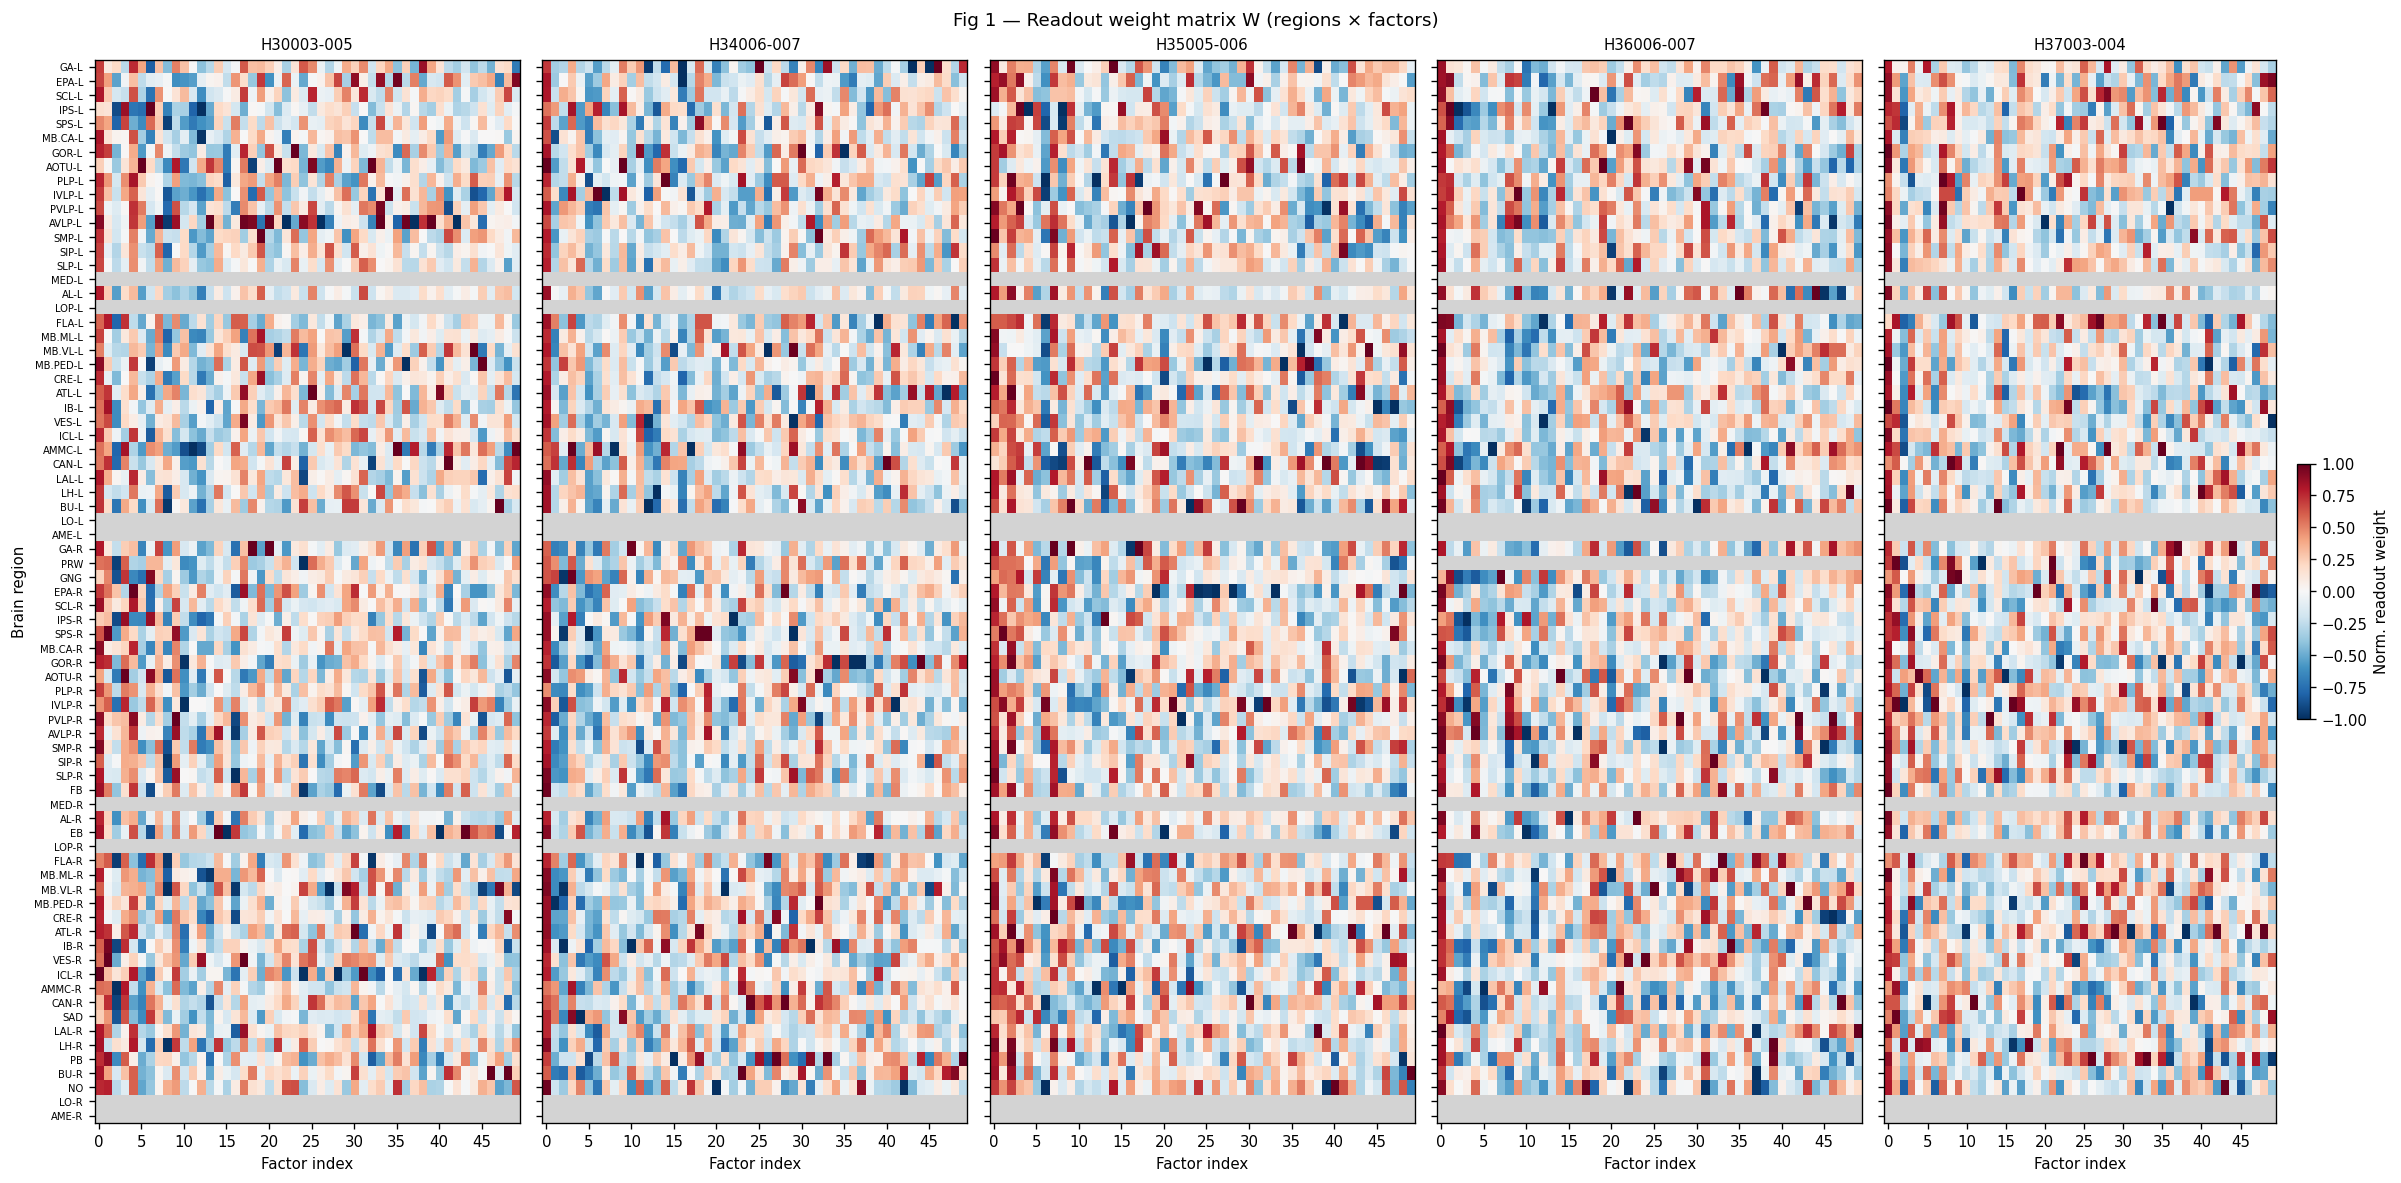

Rows = regions, cols = factors. Red = +, Blue = −, grey = region absent in that fly.


In [13]:
fig, axes = plt.subplots(1, n_flies, figsize=(4 * n_flies, 10), sharey=True)
if n_flies == 1:
    axes = [axes]
cmap = plt.get_cmap('RdBu_r').copy(); cmap.set_bad('lightgrey')
for ax, fly_stem in zip(axes, fly_stems):
    W = readout_weights[fly_stem]                              # (75, n_fac), NaN absent
    W_norm = W / (np.nanmax(np.abs(W), axis=0, keepdims=True) + 1e-12)
    im = ax.imshow(np.ma.masked_invalid(W_norm), aspect='auto', origin='lower',
                   cmap=cmap, vmin=-1, vmax=1, interpolation='nearest')
    ax.set_title(SHORT[fly_stem], fontsize=9); ax.set_xlabel('Factor index')
    if ax is axes[0]:
        ax.set_yticks(range(N_REGIONS)); ax.set_yticklabels(REGION_NAMES, fontsize=6)
        ax.set_ylabel('Brain region')
    ax.set_xticks(range(0, n_fac, 5))
plt.colorbar(im, ax=axes[-1], label='Norm. readout weight', fraction=0.03)
fig.suptitle('Fig 1 — Readout weight matrix W (regions × factors)', fontsize=11)
plt.tight_layout(); plt.show()
print('Rows = regions, cols = factors. Red = +, Blue = −, grey = region absent in that fly.')

## Fig 2 — Top regions per factor

For each factor, which regions have the largest absolute readout weight?
Averaged across flies using only regions valid in all flies.

Optic-lobe neuropils flagged as likely artifacts (`ARTIFACT_BASES` = MED/AME/LO/LOP, both
hemispheres) are **excluded from the ranking** here — set `ARTIFACT_BASES = []` to keep them.

In [31]:
# Average normalised |W| across flies (nanmean ignores regions absent in a given fly)
stack = np.stack([np.abs(readout_weights[s]) /
                  (np.nanmax(np.abs(readout_weights[s]), axis=0, keepdims=True) + 1e-12)
                  for s in fly_stems], 0)        # (n_flies, 75, n_fac)
W_abs_mean = np.nan_to_num(np.nanmean(stack, 0))  # (75, n_fac)

# Exclude flagged optic-lobe artifact regions from the ranking (zero them before argsort)
W_rank = W_abs_mean.copy()
W_rank[ARTIFACT_MASK] = 0.0
print(f'Excluding {len(ARTIFACT_REGIONS)} artifact regions: {ARTIFACT_REGIONS}\n')

TOP_N = 5
factor_max_loading = W_rank.max(axis=0)
top_factors = np.argsort(factor_max_loading)[::-1][:30]
print(f'Top {TOP_N} non-artifact regions for highest-loading factors '
      f'(mean |W| across {n_flies} flies):\n')
for j in top_factors:
    order = np.argsort(W_rank[:, j])[::-1][:TOP_N]
    names = ', '.join(f'{REGION_NAMES[r]} ({W_rank[r, j]:.2f})' for r in order)
    print(f'  Factor {j:2d}: {names}')

Excluding 8 artifact regions: ['AME-R', 'LO-R', 'LOP-R', 'MED-R', 'AME-L', 'LO-L', 'LOP-L', 'MED-L']

Top 5 non-artifact regions for highest-loading factors (mean |W| across 5 flies):

  Factor  0: FB (0.91), SMP-R (0.89), SLP-R (0.88), EB (0.87), LAL-L (0.86)
  Factor  2: IB-R (0.76), SPS-L (0.74), IVLP-R (0.72), PRW (0.70), SPS-R (0.68)
  Factor  9: IVLP-L (0.74), AOTU-L (0.60), GNG (0.53), LH-R (0.53), AOTU-R (0.50)
  Factor  1: IVLP-R (0.73), FLA-L (0.73), SPS-R (0.68), VES-R (0.65), VES-L (0.65)
  Factor  3: IPS-L (0.73), GNG (0.72), IPS-R (0.71), AMMC-L (0.69), SAD (0.69)
  Factor  6: AMMC-L (0.71), IPS-L (0.69), NO (0.59), GNG (0.57), EB (0.57)
  Factor  7: AVLP-L (0.71), EB (0.49), GA-R (0.49), IVLP-L (0.49), CRE-L (0.47)
  Factor 42: ATL-R (0.70), PVLP-R (0.50), AVLP-L (0.48), SMP-R (0.47), NO (0.46)
  Factor 44: MB.VL-L (0.70), IVLP-R (0.47), LAL-R (0.47), MB.PED-L (0.44), GOR-R (0.43)
  Factor  8: IPS-L (0.69), SPS-L (0.67), AMMC-L (0.63), CAN-L (0.61), GNG (0.55)
  Factor 1

/tmp/ipykernel_1804241/904677623.py:5: RuntimeWarning: Mean of empty slice
  W_abs_mean = np.nan_to_num(np.nanmean(stack, 0))  # (75, n_fac)


## Fig 3 — Factor-region Pearson correlation

From posterior samples: how correlated is each factor's time course with each region's
denoised ΔF/F? This is a data-driven complement to the weight matrix (W captures the
linear model; correlation captures the actual co-variance in the inferred trajectories).

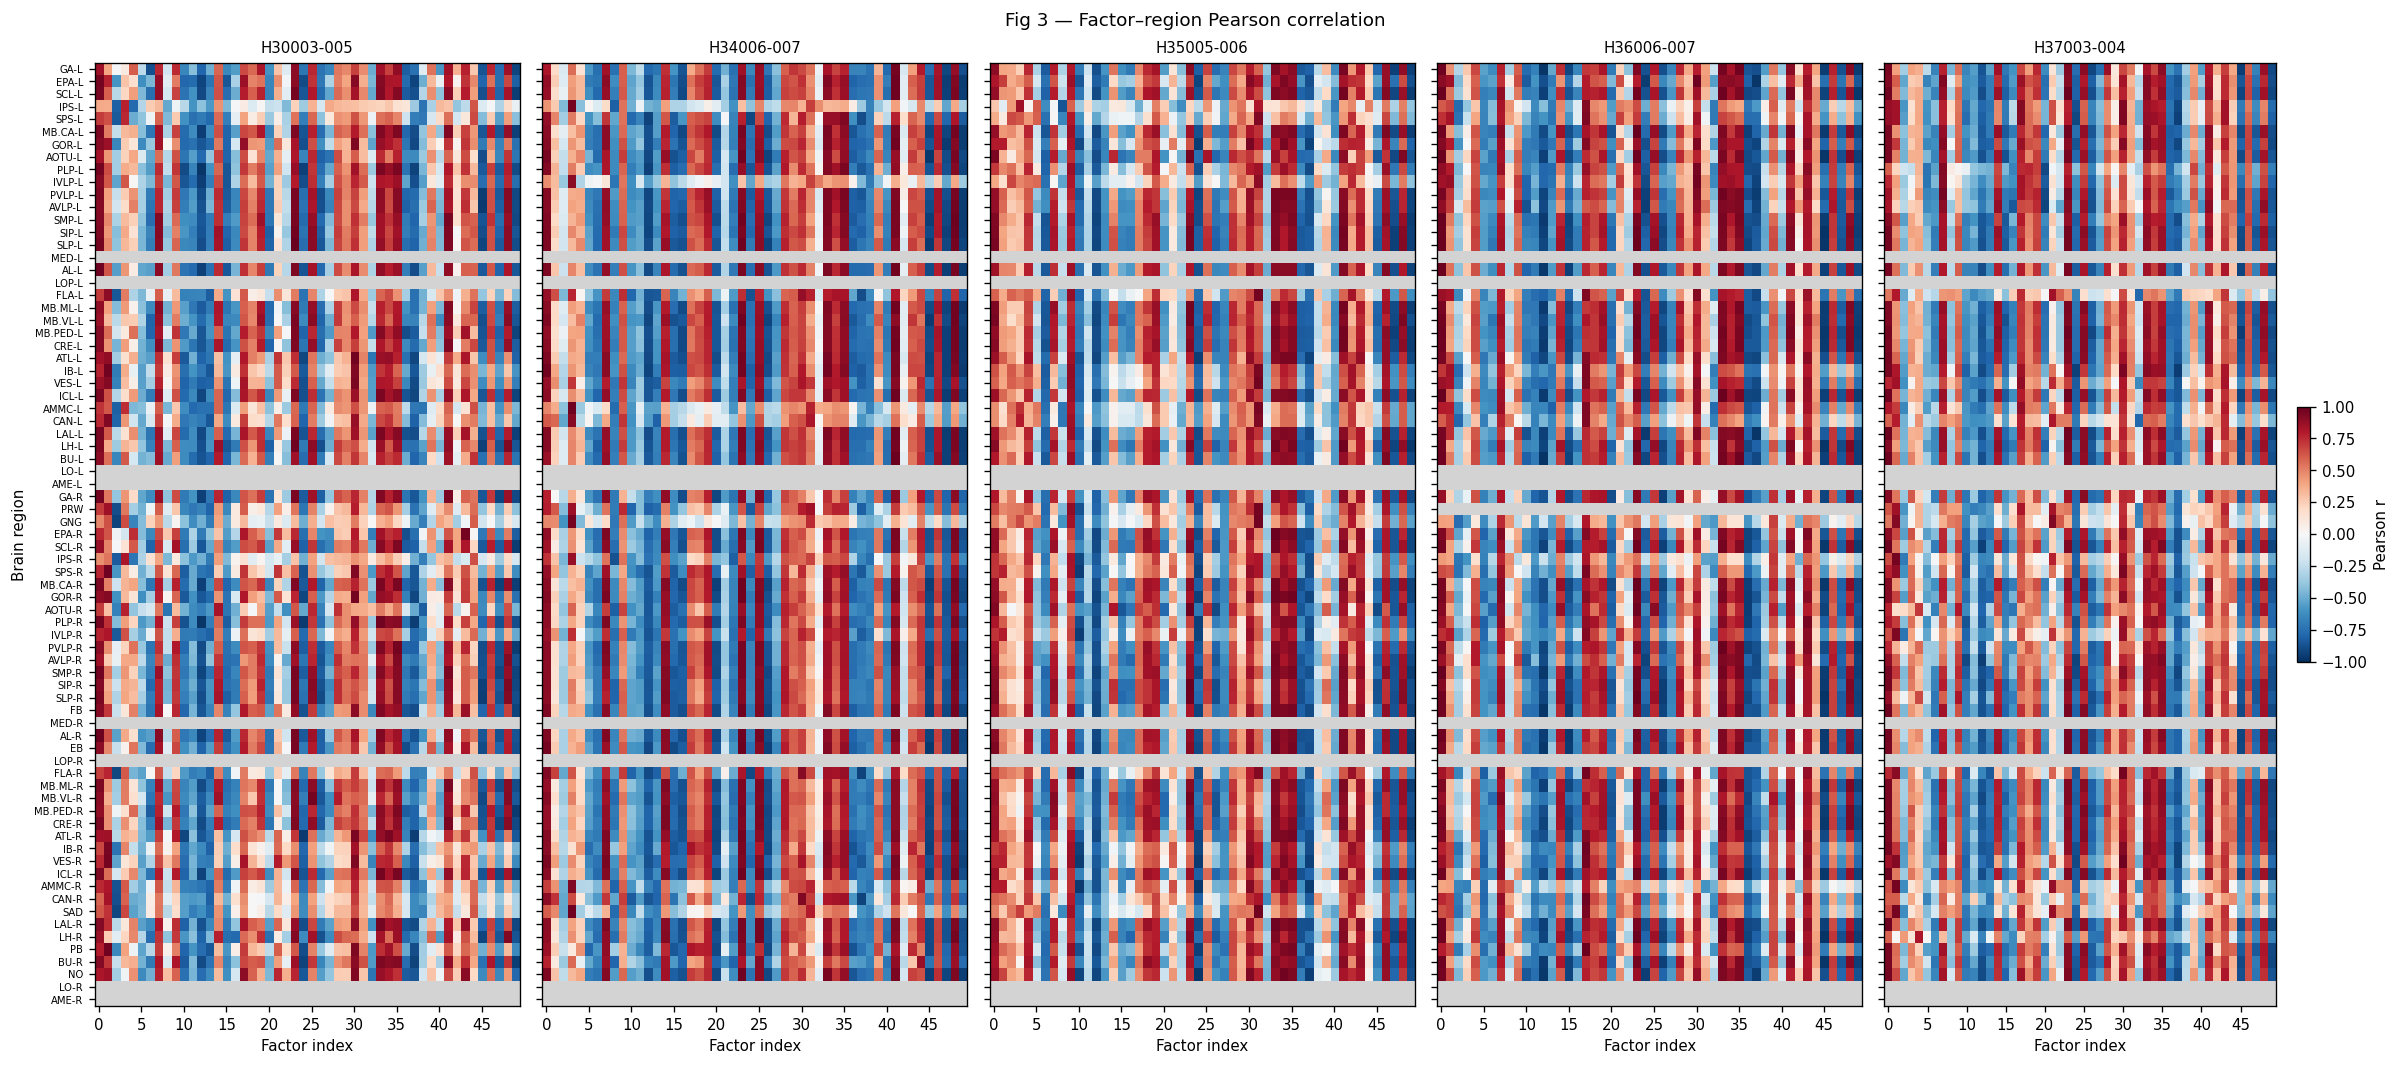

In [15]:
def factor_region_corr(factors, output_params):
    """Pearson r between each factor and each region across all trials×time."""
    n_fac = factors.shape[-1]; n_reg = output_params.shape[-1]
    F = factors.reshape(-1, n_fac); O = output_params.reshape(-1, n_reg)
    F_z = (F - F.mean(0)) / (F.std(0) + 1e-12)
    O_z = (O - O.mean(0)) / (O.std(0) + 1e-12)
    return (F_z.T @ O_z) / len(F)                 # (n_fac, n_reg)

fig, axes = plt.subplots(1, n_flies, figsize=(4 * n_flies, 9), sharey=True)
if n_flies == 1:
    axes = [axes]
cmap = plt.get_cmap('RdBu_r').copy(); cmap.set_bad('lightgrey')
for ax, fly_stem in zip(axes, fly_stems):
    d = fly_data[fly_stem]
    corr = factor_region_corr(d['factors'], d['output_params'])   # (n_fac, n_reg)
    corr_canon = to_canon(corr.T, fly_stem)                       # (75, n_fac)
    im = ax.imshow(np.ma.masked_invalid(corr_canon), aspect='auto', origin='lower',
                   cmap=cmap, vmin=-1, vmax=1, interpolation='nearest')
    ax.set_title(SHORT[fly_stem], fontsize=9); ax.set_xlabel('Factor index')
    if ax is axes[0]:
        ax.set_yticks(range(N_REGIONS)); ax.set_yticklabels(REGION_NAMES, fontsize=6)
        ax.set_ylabel('Brain region')
    ax.set_xticks(range(0, n_fac, 5))
plt.colorbar(im, ax=axes[-1], label='Pearson r', fraction=0.03)
fig.suptitle('Fig 3 — Factor–region Pearson correlation', fontsize=11)
plt.tight_layout(); plt.show()

### Fig 3b — Factor global-ness (global vs selective factors)

Quantifies the observation that several factors correlate with *almost all* regions. For each factor:
**global-ness = mean |r| across regions** (how brain-wide its coupling is) vs **peak |r| = max over
regions** (how strongly it locks to its single best region). Global-mode factors sit high on mean |r|
(broad, non-specific); selective factors have low mean but high peak (localised, interpretable).
Averaged across flies. Use this to decide which factors in Figs 1/3 are common-mode vs region-specific.

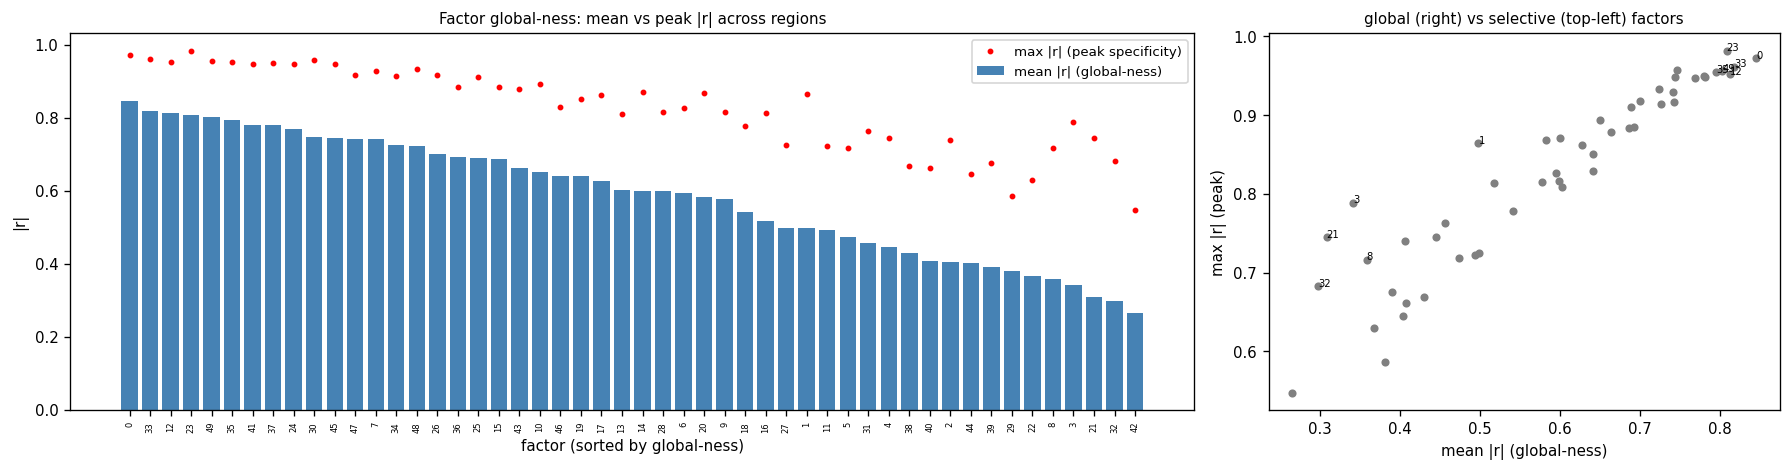

Most GLOBAL factors (high mean |r|): [0, 33, 12, 23, 49]   mean|r|= [0.85, 0.82, 0.81, 0.81, 0.8]
Most SELECTIVE factors (high peak, low mean): [3, 21, 32, 1, 8]   peak= [0.79, 0.74, 0.68, 0.86, 0.72]


In [16]:
# Global-ness (mean |r| across regions) and peak |r| per factor, averaged across flies
gness = np.zeros((n_flies, n_fac)); peak = np.zeros((n_flies, n_fac))
for k, s in enumerate(fly_stems):
    corr = factor_region_corr(fly_data[s]['factors'], fly_data[s]['output_params'])  # (n_fac, n_reg)
    gness[k] = np.abs(corr).mean(1)
    peak[k]  = np.abs(corr).max(1)
gmean = gness.mean(0); pmean = peak.mean(0)
order = np.argsort(gmean)[::-1]

fig, axs = plt.subplots(1, 2, figsize=(15, 4), gridspec_kw={'width_ratios': [2.2, 1]})
ax = axs[0]
ax.bar(range(n_fac), gmean[order], color='steelblue', label='mean |r| (global-ness)')
ax.plot(range(n_fac), pmean[order], 'r.', ms=5, label='max |r| (peak specificity)')
ax.set_xticks(range(n_fac)); ax.set_xticklabels(order, rotation=90, fontsize=5)
ax.set_xlabel('factor (sorted by global-ness)'); ax.set_ylabel('|r|')
ax.legend(fontsize=8)
ax.set_title('Factor global-ness: mean vs peak |r| across regions', fontsize=9)

ax2 = axs[1]
ax2.scatter(gmean, pmean, s=15, color='grey')
sel_score = pmean - gmean
for j in range(n_fac):
    if gmean[j] >= np.percentile(gmean, 88) or sel_score[j] >= np.percentile(sel_score, 90):
        ax2.annotate(str(j), (gmean[j], pmean[j]), fontsize=6)
ax2.set_xlabel('mean |r| (global-ness)'); ax2.set_ylabel('max |r| (peak)')
ax2.set_title('global (right) vs selective (top-left) factors', fontsize=9)
plt.tight_layout(); plt.show()

print('Most GLOBAL factors (high mean |r|):', order[:5].tolist(),
      '  mean|r|=', np.round(gmean[order[:5]], 2).tolist())
sel = np.argsort(sel_score)[::-1]
print('Most SELECTIVE factors (high peak, low mean):', sel[:5].tolist(),
      '  peak=', np.round(pmean[sel[:5]], 2).tolist())

### Fig 3c — Fig 3 after global-signal regression

Removes the brain-wide common mode before recomputing the factor-region correlation: the population
signal `g(t) = mean over regions` is regressed out of *both* the factor traces and the region traces,
then correlations are recomputed on the residuals (this is "global signal regression", as in fMRI).
The broad vertical stripes driven by the global mode collapse, leaving the **region-specific**
structure. (Regressing out factor 0 instead gives a similar result, since factor 0 ≈ the global mode.)

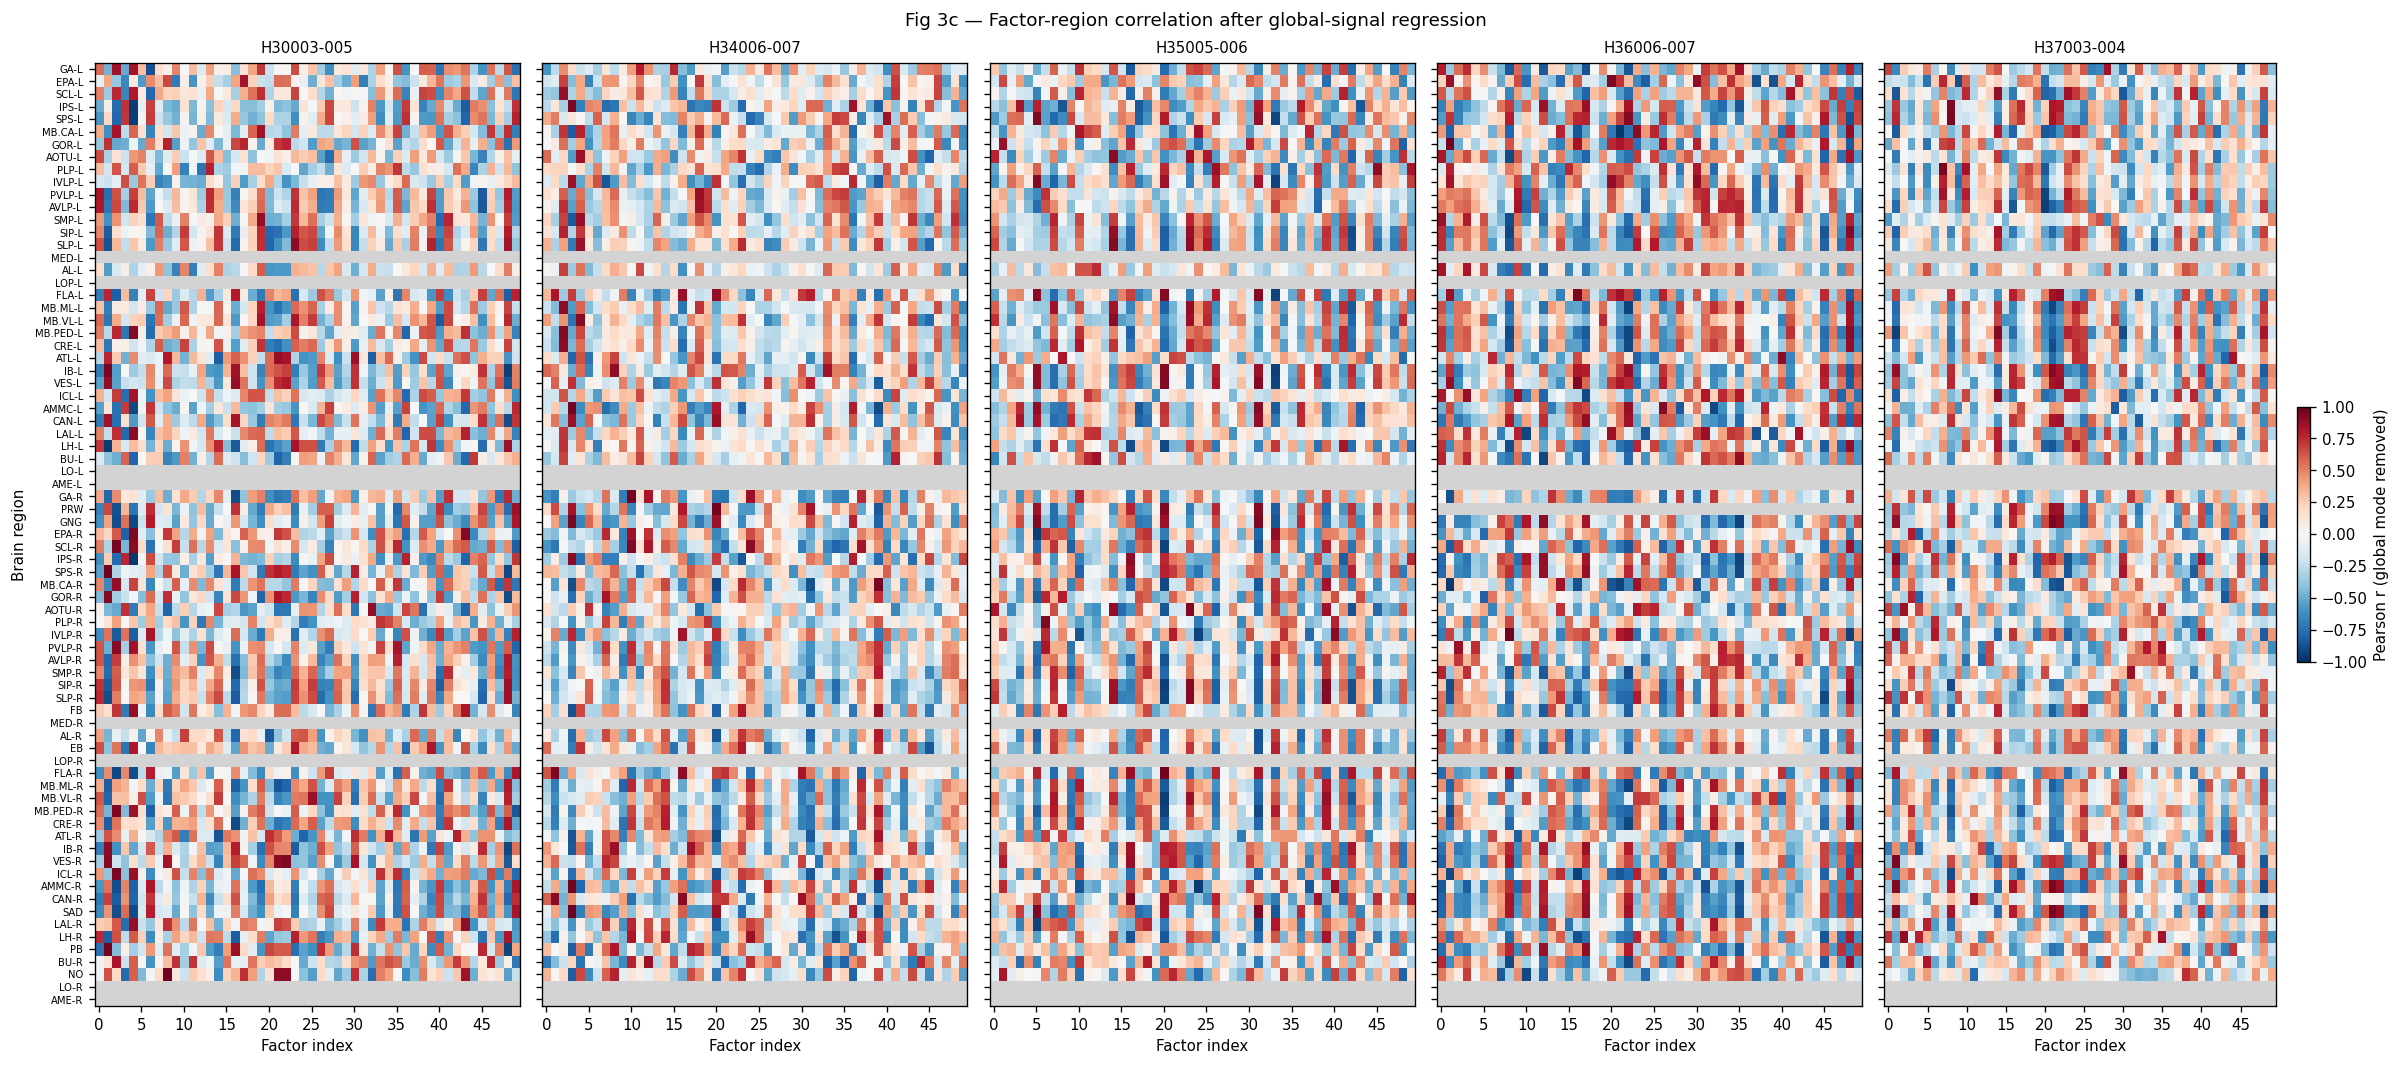

In [17]:
def gsr_corr(factors, output_params):
    '''Factor-region Pearson r AFTER regressing the brain-wide mean signal out of both.'''
    F = factors.reshape(-1, factors.shape[-1]); O = output_params.reshape(-1, output_params.shape[-1])
    g = O.mean(1, keepdims=True); G = np.column_stack([g, np.ones(len(g))])
    def resid(X):
        b, *_ = np.linalg.lstsq(G, X, rcond=None); return X - G @ b
    Fr = resid(F); Or = resid(O)
    Fz = (Fr - Fr.mean(0)) / (Fr.std(0) + 1e-12)
    Oz = (Or - Or.mean(0)) / (Or.std(0) + 1e-12)
    return (Fz.T @ Oz) / len(Fr)

fig, axes = plt.subplots(1, n_flies, figsize=(4 * n_flies, 9), sharey=True)
if n_flies == 1:
    axes = [axes]
cmap = plt.get_cmap('RdBu_r').copy(); cmap.set_bad('lightgrey')
for ax, s in zip(axes, fly_stems):
    corr = gsr_corr(fly_data[s]['factors'], fly_data[s]['output_params'])   # (n_fac, n_reg)
    cc = to_canon(corr.T, s)                                                # (75, n_fac)
    im = ax.imshow(np.ma.masked_invalid(cc), aspect='auto', origin='lower',
                   cmap=cmap, vmin=-1, vmax=1, interpolation='nearest')
    ax.set_title(SHORT[s], fontsize=9); ax.set_xlabel('Factor index')
    if ax is axes[0]:
        ax.set_yticks(range(N_REGIONS)); ax.set_yticklabels(REGION_NAMES, fontsize=6)
        ax.set_ylabel('Brain region')
    ax.set_xticks(range(0, n_fac, 5))
plt.colorbar(im, ax=axes[-1], label='Pearson r (global mode removed)', fraction=0.03)
fig.suptitle('Fig 3c — Factor-region correlation after global-signal regression', fontsize=11)
plt.tight_layout(); plt.show()

## Fig 4 — Region variance composition over orthogonal factor modes

The reconstructed signal for region *i* is `x̂ᵢ = Σⱼ W[i,j]·fⱼ + bᵢ`. A naive per-factor variance split
(`W[i,j]²·Var(fⱼ)`) is **invalid here**: the 50 factors are highly collinear (mean |corr| ≈ 0.5,
**effective dimensionality ≈ 4**), so ~70% of each region's variance lives in factor cross-terms the
naive split ignores.

Instead we decompose over the **orthogonal eigen-modes** of each fly's factor covariance
(`Σ_f = V·diag(λ)·Vᵀ`): `Var(x̂ᵢ) = Σₖ (wᵢ·vₖ)²·λₖ` is then **exact** (no cross-terms). Each row is the
fraction of region *i*'s reconstructed variance carried by each orthogonal mode (mode 0 = the
dominant, largely global mode). The printed **participation ratio** is the effective number of
independent factor dimensions. Modes are ordered by variance per fly (not comparable across flies).

The reconstructed activity of region i is a linear mix of the 50 factors: x̂ᵢ(t) = Σⱼ W[i,j]·fⱼ(t) + bᵢ. If you treat the factors as roughly uncorrelated, the variance of that region's signal splits into per-factor pieces:


Var(x̂ᵢ) ≈ Σⱼ  W[i,j]² · Var(fⱼ)
Fig 4 plots each of those pieces normalized so each region's row sums to 1:


frac[i,j] = W[i,j]²·Var(fⱼ)  /  Σₖ W[i,k]²·Var(fₖ)
So each row is a "pie": the fraction of region i's reconstructed variance that each factor accounts for. It answers "what is this region's signal made of, in factor terms, and in what proportions?" (Only the top-20 factors by mean share are shown, sorted per fly, for readability — the row still sums to ~1 because those 20 carry almost all of it.)

Practically, Fig 4's best use here is spotting the near-single-factor regions (candidates for a clean region↔factor mapping) and confirming that most regions are dominated by a small number of high-variance (largely global) factors — the same low-dimensional story as Fig 3b. 

Factor-space effective dimensionality (participation ratio): 3.5 / 50 (pooled)  |  top mode = 48% of factor variance, top-3 = 75%


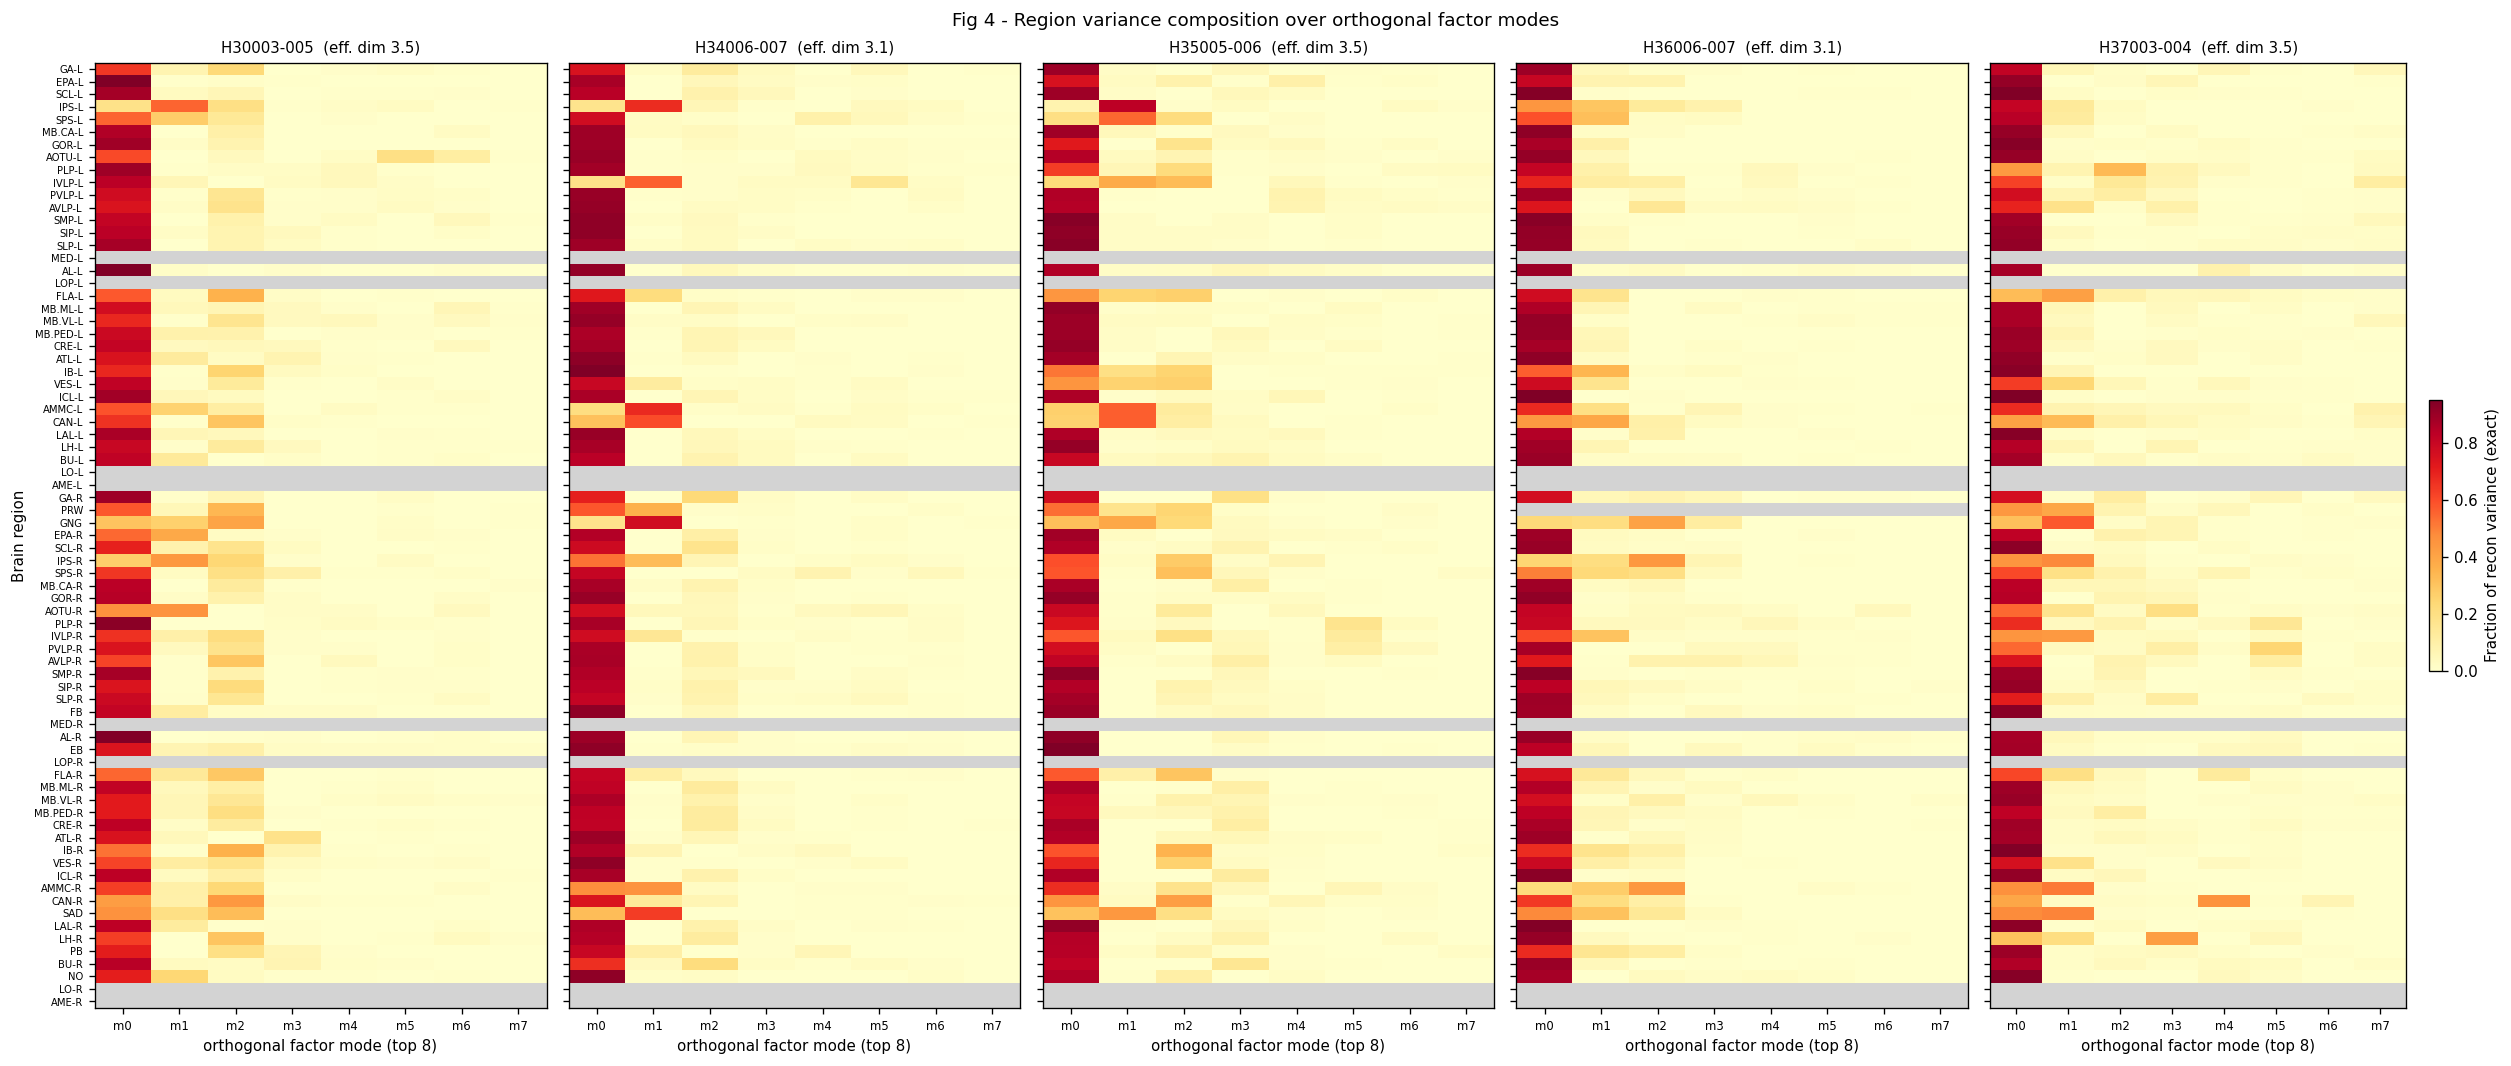

Mode 0 = dominant (largely global) mode; each row sums to 1 over ALL modes. Columns are per-fly, not comparable across flies.


In [18]:
from numpy.linalg import eigh

# Effective dimensionality (participation ratio) of the shared factor space, pooled across flies
allF = np.concatenate([fly_data[s]['factors'].reshape(-1, n_fac) for s in fly_stems], 0)
lam_pool = np.sort(np.linalg.eigvalsh(np.cov(allF.T)))[::-1]; lam_pool = lam_pool[lam_pool > 0]
PR_pool = lam_pool.sum() ** 2 / (lam_pool ** 2).sum()
print(f'Factor-space effective dimensionality (participation ratio): {PR_pool:.1f} / {n_fac} (pooled)'
      f'  |  top mode = {lam_pool[0] / lam_pool.sum():.0%} of factor variance, '
      f'top-3 = {lam_pool[:3].sum() / lam_pool.sum():.0%}')

K = 8   # show the top-K orthogonal modes (effective dim ~4, so this captures nearly all variance)
fig, axes = plt.subplots(1, n_flies, figsize=(4.2 * n_flies, 9), sharey=True)
if n_flies == 1:
    axes = [axes]
cmap = plt.get_cmap('YlOrRd').copy(); cmap.set_bad('lightgrey')
for ax, s in zip(axes, fly_stems):
    Wn = readout_W[s]                                        # native (n_reg, n_fac)
    Sig = np.cov(fly_data[s]['factors'].reshape(-1, n_fac).T)
    lam, V = eigh(Sig)                                       # ascending
    o = np.argsort(lam)[::-1]; lam = lam[o]; V = V[:, o]     # descending by variance
    proj = Wn @ V                                            # (n_reg, n_fac): region loading per mode
    contrib = (proj ** 2) * lam[np.newaxis, :]              # exact variance per mode (modes orthogonal)
    frac = contrib / (contrib.sum(1, keepdims=True) + 1e-12)
    PR = lam.sum() ** 2 / (lam ** 2).sum()
    frac_canon = to_canon(frac[:, :K], s)                   # (75, K)
    im = ax.imshow(np.ma.masked_invalid(frac_canon), aspect='auto', origin='lower',
                   cmap=cmap, vmin=0, vmax=np.nanmax(frac_canon), interpolation='nearest')
    ax.set_title(f'{SHORT[s]}  (eff. dim {PR:.1f})', fontsize=9)
    ax.set_xlabel(f'orthogonal factor mode (top {K})')
    ax.set_xticks(range(K)); ax.set_xticklabels([f'm{k}' for k in range(K)], fontsize=7)
    if ax is axes[0]:
        ax.set_yticks(range(N_REGIONS)); ax.set_yticklabels(REGION_NAMES, fontsize=6)
        ax.set_ylabel('Brain region')
plt.colorbar(im, ax=axes[-1], label='Fraction of recon variance (exact)', fraction=0.03)
fig.suptitle('Fig 4 - Region variance composition over orthogonal factor modes', fontsize=11)
plt.tight_layout(); plt.show()
print('Mode 0 = dominant (largely global) mode; each row sums to 1 over ALL modes. '
      'Columns are per-fly, not comparable across flies.')

## Fig 4.1 — Latent trajectories of the orthogonal factor modes

Fig 4 decomposed region variance over the factor-covariance eigen-modes. Those modes have **time
courses** — the factors projected onto each eigenvector — i.e. the decorrelated latent trajectories.
Here we use the **pooled** mode basis (a common, cross-fly-comparable set of orthogonal axes) and show:
(a) the condition-averaged time course of the top modes, and (b) the condition-mean trajectories in
the top orthogonal modes. **Mode 0** is the dominant global mode (the stimulus-locked ramp shared by
all conditions); condition-specific structure lives in the higher modes (m1-m3).

> **Mode signs are arbitrary** (v and −v are equivalent). We fix them so each mode's *dominant-region* readout loading is positive (dominant region ↑ ⇔ mode ↑), so polarities match the ΔF/F signal.

Manually flipped modes: [1]
Sign convention: dominant NON-ARTIFACT region loading positive.  Top-4 modes:
  mode 0: 48% var, dominant non-artifact region SLP-L (loading +0.30)
  mode 1: 15% var, dominant non-artifact region SPS-R (loading -0.18)
  mode 2: 12% var, dominant non-artifact region PRW (loading +0.22)
  mode 3: 10% var, dominant non-artifact region IPS-L (loading +0.13)   [flipped]


/tmp/ipykernel_1804241/1717248950.py:16: RuntimeWarning: Mean of empty slice
  Lm = np.nanmean(np.stack([np.stack([to_canon(readout_W[s] @ VP[:, k], s)


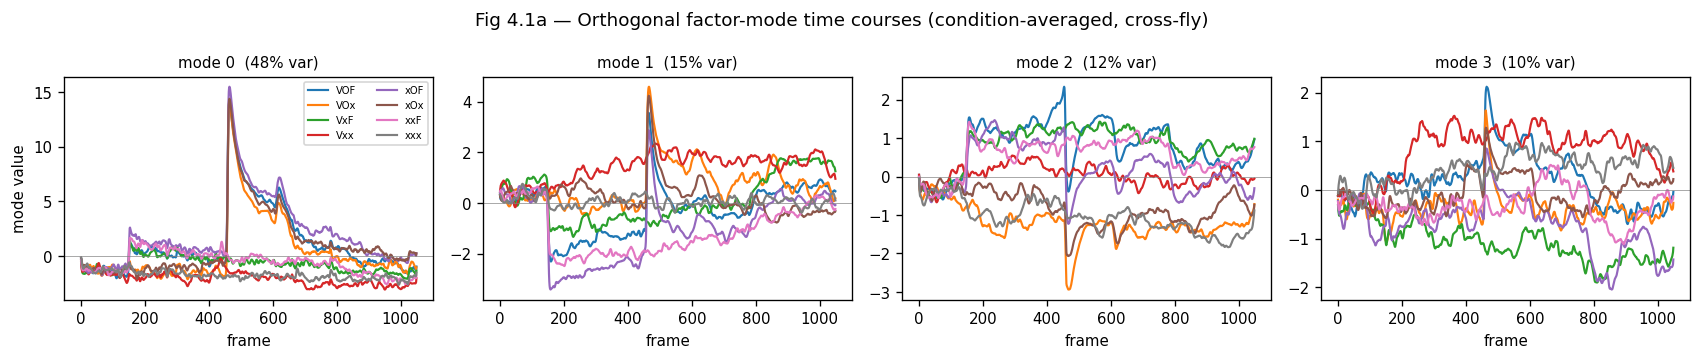

Text(0.5, 0.98, 'Fig 4.1b — Cross-fly condition-mean trajectories in the top orthogonal modes')

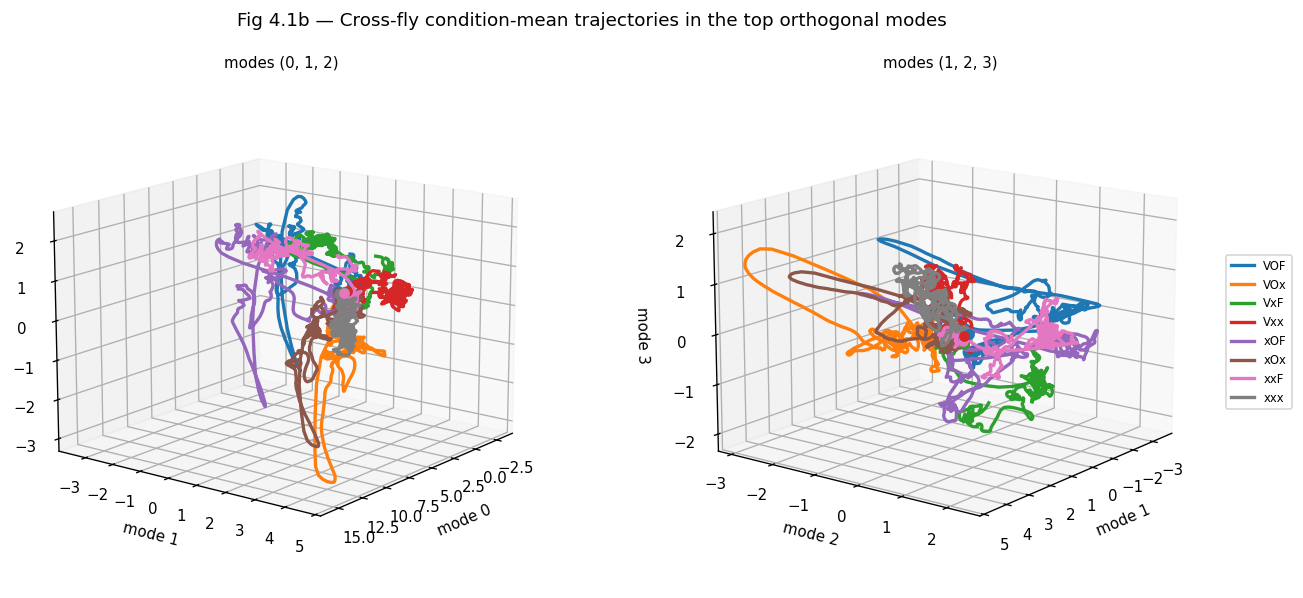

In [19]:
from numpy.linalg import eigh
from matplotlib import cm

# Common orthogonal mode basis from the POOLED factor covariance (comparable across flies)
allF = np.concatenate([fly_data[s]['factors'].reshape(-1, n_fac) for s in fly_stems], 0)
lamP, VP = eigh(np.cov(allF.T)); o = np.argsort(lamP)[::-1]; lamP = lamP[o]; VP = VP[:, o]
n_time = fly_data[fly_stems[0]]['factors'].shape[1]

# Manual sign override (applied on top of the auto convention below): flip these mode indices
# to match your expected signal polarity. You flagged mode 1 as inverted, so it's flipped here.
MODE_FLIP = [1]

# Eigenvector signs are arbitrary (v_k and -v_k are equivalent), so a mode's polarity is not
# meaningful on its own. Fix a physiological convention: orient each mode so the region it MOST
# strongly drives has a POSITIVE readout loading (dominant region's ΔF/F up  <=>  mode value up).
Lm = np.nanmean(np.stack([np.stack([to_canon(readout_W[s] @ VP[:, k], s)
                                    for k in range(n_fac)], axis=1)
                          for s in fly_stems], 0), 0)                      # (75, n_fac)
# anchor to the dominant NON-ARTIFACT region (optic-lobe artifacts dominate modes 1-3 and must
# not set the polarity), so mode signs track the real ΔF/F signal
Lm_anchor = Lm.copy(); Lm_anchor[ARTIFACT_MASK] = np.nan
flip = np.ones(n_fac)
for k in range(n_fac):
    col = Lm_anchor[:, k]
    if not np.all(np.isnan(col)):
        flip[k] = np.sign(col[np.nanargmax(np.abs(col))]) or 1.0
VP = VP * flip[np.newaxis, :]; Lm = Lm * flip[np.newaxis, :]; Lm_anchor = Lm_anchor * flip[np.newaxis, :]
man = np.ones(n_fac);
for _k in MODE_FLIP: man[_k] = -1.0
VP = VP * man[np.newaxis, :]; Lm = Lm * man[np.newaxis, :]; Lm_anchor = Lm_anchor * man[np.newaxis, :]
if MODE_FLIP: print('Manually flipped modes:', MODE_FLIP)
print('Sign convention: dominant NON-ARTIFACT region loading positive.  Top-4 modes:')
for k in range(4):
    i = np.nanargmax(np.abs(Lm_anchor[:, k]))
    print(f'  mode {k}: {lamP[k] / lamP.sum():.0%} var, dominant non-artifact region '
          f'{REGION_NAMES[i]} (loading {Lm[i, k]:+.2f}){"   [flipped]" if flip[k] < 0 else ""}')

# 8-way stimulus condition labels per fly (from the xarray)
COND_ORDER = ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
cond = {s: cond_for(s) for s in fly_stems}   # baseline trials [0,9] dropped to match 16-trial h5s
colors = {c: cm.tab10(i % 10) for i, c in enumerate(COND_ORDER)}

# project each fly's factors onto the (sign-fixed) pooled modes -> (trials, time, n_fac)
modes = {s: (fly_data[s]['factors'].reshape(-1, n_fac) @ VP).reshape(-1, n_time, n_fac)
         for s in fly_stems}

# (a) time courses of the top-K modes, condition-averaged across flies
K = 4
fig, axes = plt.subplots(1, K, figsize=(3.6 * K, 3), sharex=True)
for k in range(K):
    ax = axes[k]
    for c in COND_ORDER:
        tr = [modes[s][cond[s] == c, :, k].mean(0) for s in fly_stems if (cond[s] == c).any()]
        ax.plot(np.mean(tr, 0), color=colors[c], lw=1.3, label=c)
    ax.axhline(0, color='grey', lw=0.4)
    ax.set_title(f'mode {k}  ({lamP[k] / lamP.sum():.0%} var)', fontsize=9)
    ax.set_xlabel('frame')
axes[0].set_ylabel('mode value')
axes[0].legend(fontsize=6, ncol=2)
fig.suptitle('Fig 4.1a — Orthogonal factor-mode time courses (condition-averaged, cross-fly)',
             fontsize=11)
plt.tight_layout(); plt.show()

# (b) 3D condition-mean trajectories in the top orthogonal modes: m0-m1-m2 and m1-m2-m3
fig = plt.figure(figsize=(13, 5.5))
for j, pcs in enumerate([(0, 1, 2), (1, 2, 3)]):
    ax = fig.add_subplot(1, 2, j + 1, projection='3d')
    for c in COND_ORDER:
        means = [modes[s][cond[s] == c].mean(0) for s in fly_stems if (cond[s] == c).any()]
        mt = np.mean(means, 0)[:, list(pcs)]
        ax.plot(*mt.T, color=colors[c], lw=2, label=c)
        ax.scatter(*mt[0], color=colors[c], s=30)
    ax.set_xlabel(f'mode {pcs[0]}'); ax.set_ylabel(f'mode {pcs[1]}'); ax.set_zlabel(f'mode {pcs[2]}')
    ax.set_title(f'modes {pcs}', fontsize=9); ax.view_init(elev=15., azim=37.5)
ax.legend(fontsize=7, loc='center left', bbox_to_anchor=(1.05, 0.5))
fig.suptitle('Fig 4.1b — Cross-fly condition-mean trajectories in the top orthogonal modes',
             fontsize=11)


## Fig 5 — Per-region reconstruction R² (model vs data)

Per-region R² of the **model reconstruction** (`output_params`) against the **ground-truth z-scored
ΔF/F** (`recon_data`), over all (trial × time) samples — the real per-region "did it train well"
failsafe, across all non-dead regions. Low R² = a region the shared 50-factor space reconstructs
poorly (candidate for a fly-specific or noisy region).

> Note: regressing `factors → output_params` (the earlier version) is ≈1 by construction because the
> readout is *linear*, so it only checks OLS recovery — not fit to data. Comparing to `recon_data` is
> the meaningful check.

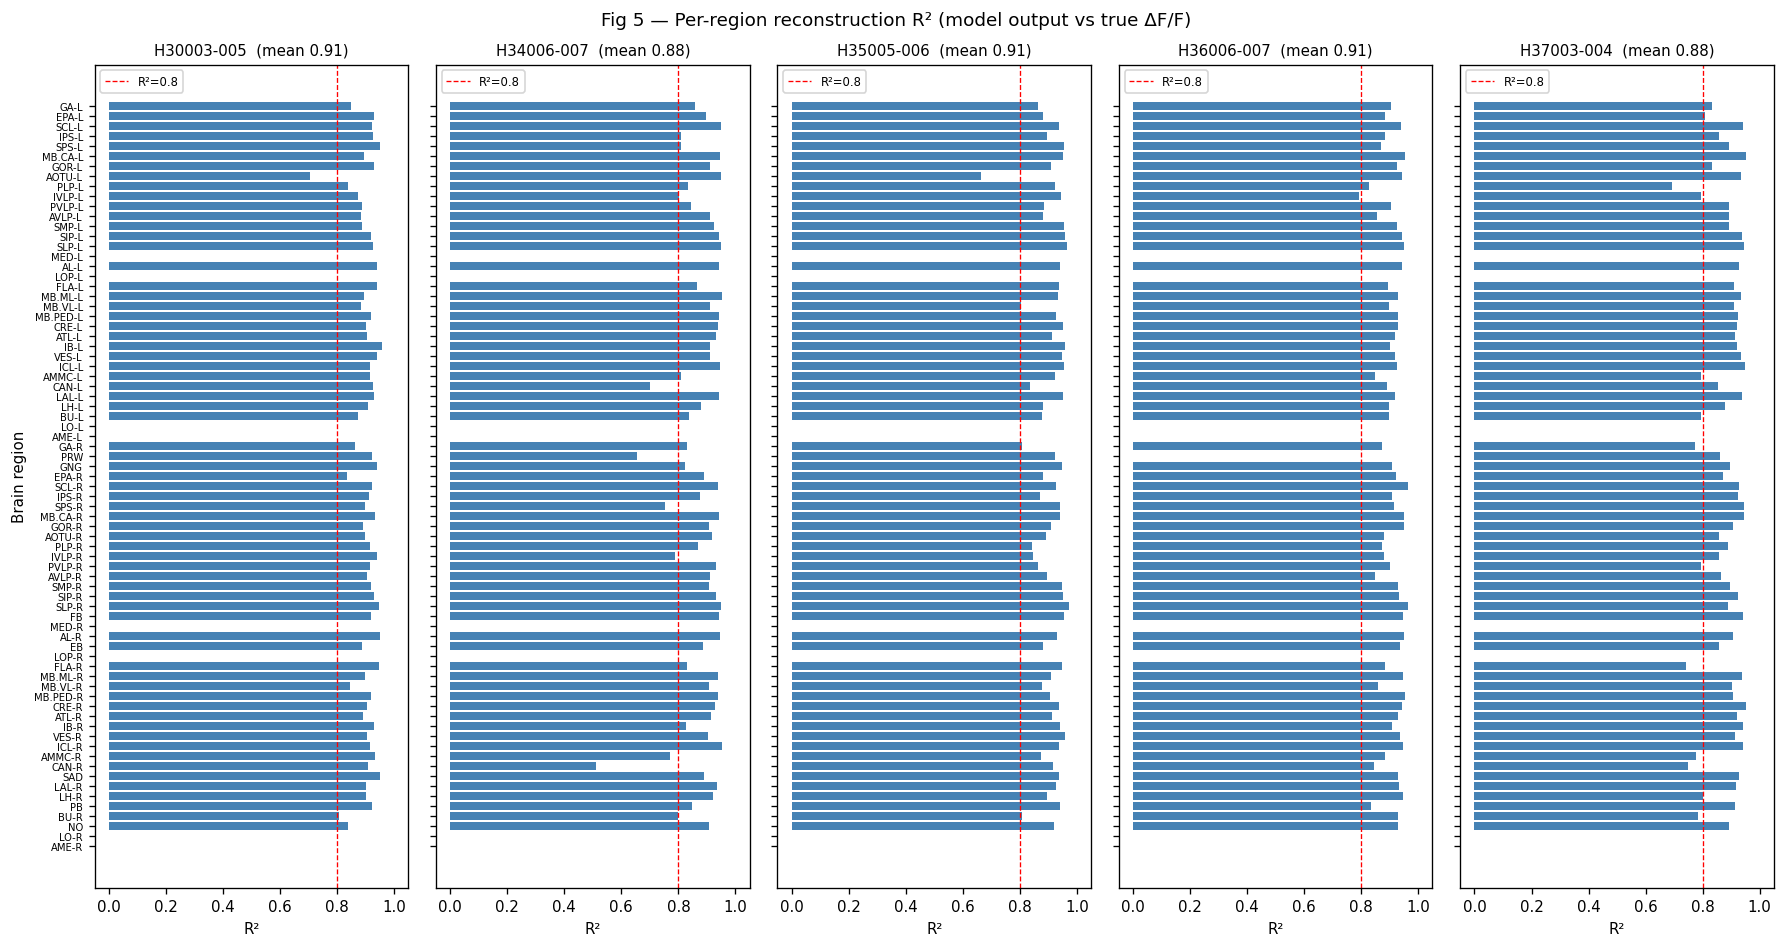

Per-fly mean per-region R²: {'H30003-005': 0.905, 'H34006-007': 0.882, 'H35005-006': 0.91, 'H36006-007': 0.911, 'H37003-004': 0.884}
Grey bars = region absent in that fly.


In [20]:
def per_region_r2(target, pred):
    '''R^2 of `pred` against `target` per region, over all (trial x time) samples.'''
    T = target.reshape(-1, target.shape[-1]); P = pred.reshape(-1, pred.shape[-1])
    ss_res = ((T - P) ** 2).sum(0); ss_tot = ((T - T.mean(0)) ** 2).sum(0)
    return 1 - ss_res / (ss_tot + 1e-12)

fig, axes = plt.subplots(1, n_flies, figsize=(3 * n_flies, 8), sharey=True)
if n_flies == 1:
    axes = [axes]
means = {}
for ax, fly_stem in zip(axes, fly_stems):
    d = fly_data[fly_stem]
    r2 = per_region_r2(d['recon_data'], d['output_params'])   # model reconstruction vs true zscored ΔF/F
    means[fly_stem] = np.nanmean(r2)
    r2_canon = to_canon(r2, fly_stem)                          # (75,) NaN where region absent
    present = valid_mask[fly_stem]
    vals = np.where(present, np.nan_to_num(r2_canon), 0.0)
    colors = ['steelblue' if present[i] else 'lightgrey' for i in range(N_REGIONS)]
    ax.barh(range(N_REGIONS), vals, color=colors, height=0.8)
    ax.axvline(0.8, color='red', lw=0.8, ls='--', label='R²=0.8')
    ax.set_xlim(-0.05, 1.05); ax.set_title(f'{SHORT[fly_stem]}  (mean {means[fly_stem]:.2f})', fontsize=9)
    ax.set_xlabel('R²')
    if ax is axes[0]:
        ax.set_yticks(range(N_REGIONS)); ax.set_yticklabels(REGION_NAMES, fontsize=6)
        ax.set_ylabel('Brain region')
    ax.legend(fontsize=7)
fig.suptitle('Fig 5 — Per-region reconstruction R² (model output vs true ΔF/F)', fontsize=11)
plt.tight_layout(); plt.show()
print('Per-fly mean per-region R²:', {SHORT[s]: round(means[s], 3) for s in fly_stems})
print('Grey bars = region absent in that fly.')

## Fig 6 — Readin vs. readout, and deviation from PCR init

Readin (`readin_weight`, straight from the h5) and readout (OLS-recovered). At PCR initialization the
readout is set to **pinv(readin)**, *not* to readin itself — so readout and readin are **not** directly
comparable (here corr(readout, readin) ≈ 0.1, whereas corr(readout, pinv(readin)) ≈ 0.86). The third
row therefore plots **readout − pinv(readin)** (both column-normalised): the deviation from the PCR
initialization, i.e. how much training actually moved the readout. Values near 0 ⇒ training barely
moved from init; `mean|Δ|` per fly is printed in each column's x-label.

corr(readout, readin) vs corr(readout, pinv(readin)) per fly:
  H30003-005: +0.08  vs  +0.89
  H34006-007: +0.08  vs  +0.90
  H35005-006: +0.11  vs  +0.92
  H36006-007: +0.09  vs  +0.89
  H37003-004: +0.12  vs  +0.93


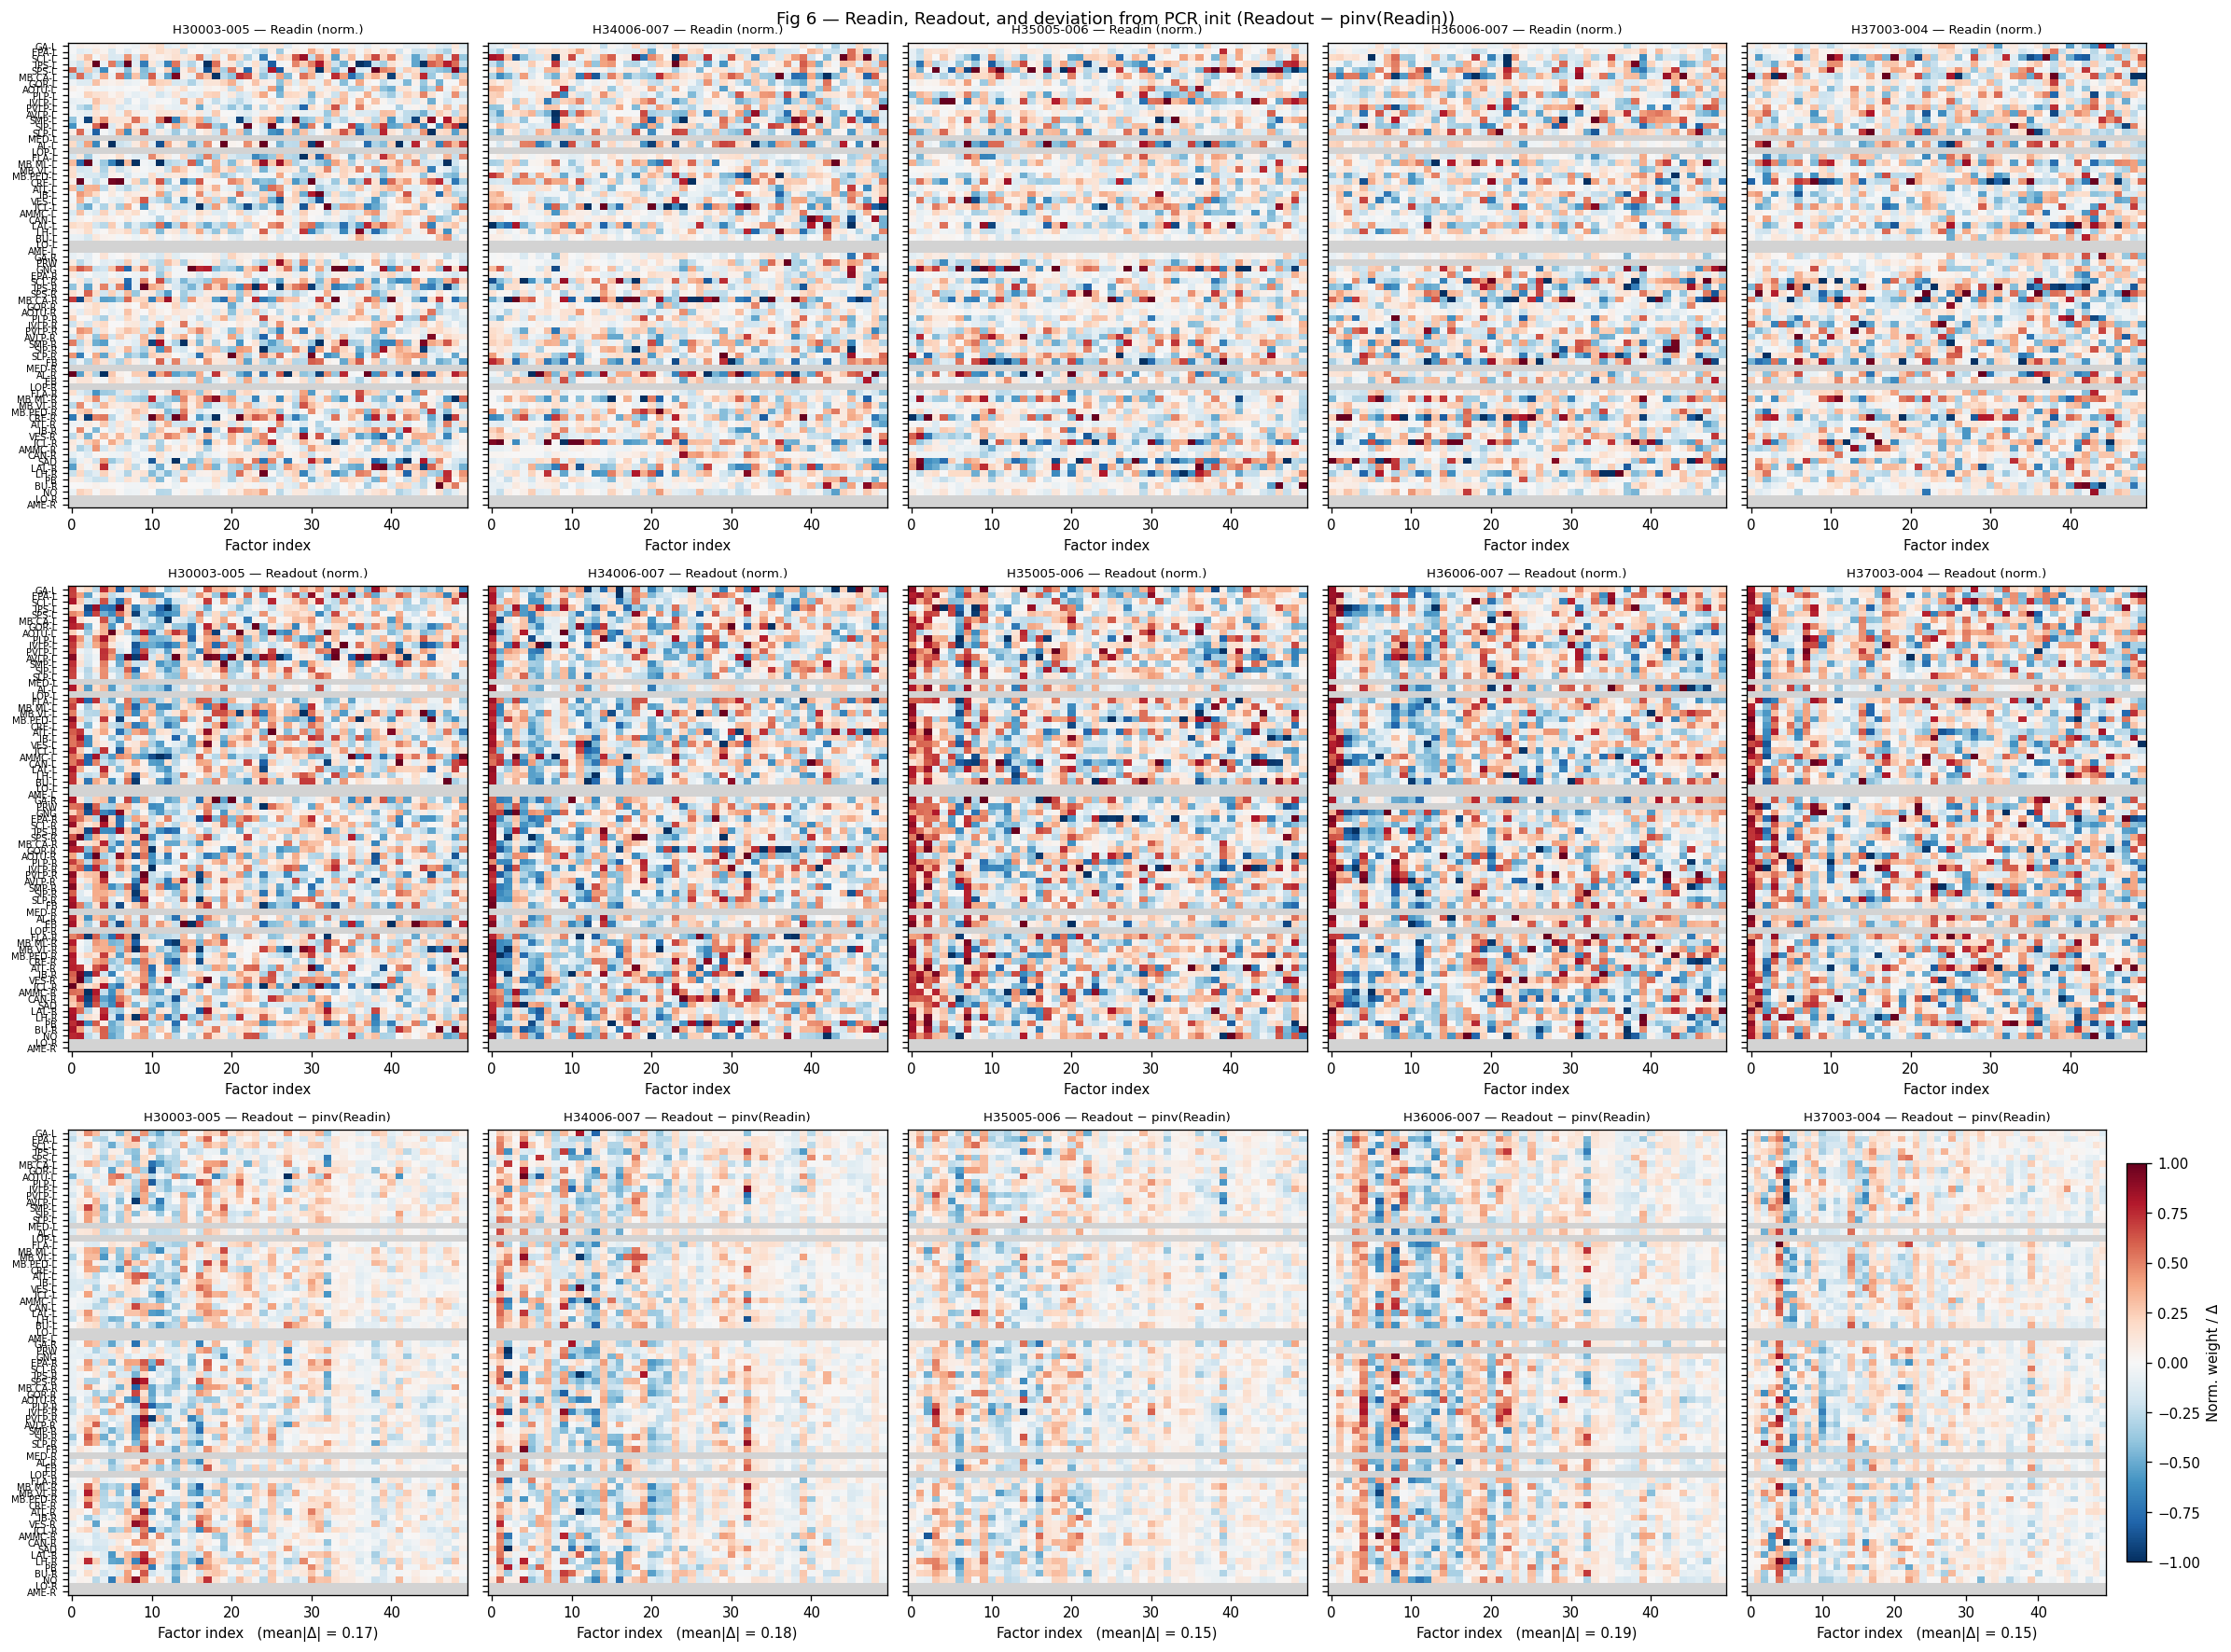

In [21]:
# Readout is initialised at PCR as pinv(readin) — NOT readin itself — so plot the deviation from
# that init, readout - pinv(readin), which is what should be ~0 if training barely moved.
print('corr(readout, readin) vs corr(readout, pinv(readin)) per fly:')
for s in fly_stems:
    Wo = readout_W[s]; Wi = fly_data[s]['readin']
    print(f'  {SHORT[s]}: {np.corrcoef(Wo.ravel(), Wi.ravel())[0,1]:+.2f}  vs  '
          f'{np.corrcoef(Wo.ravel(), np.linalg.pinv(Wi).T.ravel())[0,1]:+.2f}')

def cnorm(A): return A / (np.nanmax(np.abs(A), 0, keepdims=True) + 1e-12)
fig, axes = plt.subplots(3, n_flies, figsize=(4 * n_flies, 15), sharey='row')
if n_flies == 1:
    axes = axes[:, np.newaxis]
cmap = plt.get_cmap('RdBu_r').copy(); cmap.set_bad('lightgrey')
for col, fly_stem in enumerate(fly_stems):
    init = np.linalg.pinv(fly_data[fly_stem]['readin']).T          # PCR-init readout, native
    diff_native = readout_W[fly_stem] - init
    rows = [(readin_weights[fly_stem], 'Readin (norm.)'),
            (readout_weights[fly_stem], 'Readout (norm.)'),
            (to_canon(cnorm(readout_W[fly_stem]) - cnorm(init), fly_stem),
             'Readout − pinv(Readin)')]
    for r, (Wc, title) in enumerate(rows):
        A = cnorm(Wc) if r < 2 else Wc                            # diff row already normalised
        ax = axes[r, col]
        im = ax.imshow(np.ma.masked_invalid(A), aspect='auto', origin='lower',
                       cmap=cmap, vmin=-1, vmax=1)
        ax.set_title(f'{SHORT[fly_stem]} — {title}', fontsize=8); ax.set_xlabel('Factor index')
        if col == 0:
            ax.set_yticks(range(N_REGIONS)); ax.set_yticklabels(REGION_NAMES, fontsize=6)
    md = np.nanmean(np.abs(cnorm(readout_W[fly_stem]) - cnorm(init)))
    axes[2, col].set_xlabel(f'Factor index   (mean|Δ| = {md:.2f})')
plt.colorbar(im, ax=axes[-1, -1], label='Norm. weight / Δ', fraction=0.05)
fig.suptitle('Fig 6 — Readin, Readout, and deviation from PCR init (Readout − pinv(Readin))', fontsize=11)
plt.tight_layout(); plt.show()

pinv is the Moore–Penrose pseudoinverse — the generalization of "matrix inverse" to non-square matrices.

Why you need it here: the readin maps regions → factors (e.g. 69 regions → 50 factors). That matrix is rectangular, so it has no true inverse — you can't uniquely go back from 50 numbers to 69. The pseudoinverse gives you the best least-squares "undo": the matrix that maps factors → regions and reconstructs the original region activity as closely as possible.

So concretely:

readin : x (regions) → z (factors), i.e. z = W_in · x
pinv(readin) : z (factors) → x̂ (regions), the least-squares reconstruction x̂ = pinv(W_in) · z
That's exactly what a decoder/readout should do — invert the encoder's projection. Which is why LFADS initializes the readout as pinv(readin): start the decoder as the optimal linear undo of the encoder, then let training refine it. And it's why in Fig 6 the readout correlates with pinv(readin) (0.86) and not with readin itself (0.10) — readin and its pseudoinverse are different objects (roughly a transpose plus a rescaling), so comparing readout to raw readin is comparing a map to its own inverse.

The one-line math: for a full-row-rank A (n_fac × n_reg, with n_fac < n_reg),


pinv(A) = Aᵀ (A Aᵀ)⁻¹
and in the special case where A's rows are orthonormal (as in a pure PC basis), this collapses to just pinv(A) = Aᵀ. So for PCR, "reconstruct via pinv(readin)" is essentially "project onto the PC subspace and map back" — the standard PCA reconstruction. The (A Aᵀ)⁻¹ factor is what corrects for the readin's rows not being perfectly orthonormal/unit-scale.

So in plain terms: pinv(In) is the best linear way to rebuild each region's activity from the 50 latent factors — the natural starting point for the readout, and the thing Fig 6's third row measures training's departure from.

## Fig 7 — Cross-fly consistency of region loadings

Are the same regions consistently important across flies?
For each region, compute its mean absolute readout weight norm across factors,
then compare this scalar "region importance" across flies.

> Optic-lobe artifact regions (`ARTIFACT_REGIONS`, set by `ARTIFACT_BASES`) are **excluded** from the rankings/hubs below and shown grey in the heatmaps.

/tmp/ipykernel_1804241/1553876150.py:5: RuntimeWarning: Mean of empty slice
  importance[fly_stem] = np.nanmean(W_norm, axis=1)
/tmp/ipykernel_1804241/1553876150.py:10: RuntimeWarning: Mean of empty slice
  mean_importance = np.nanmean(imp_matrix, axis=1)
/home/kyc_hpz8/anaconda3/envs/lfads-torch/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


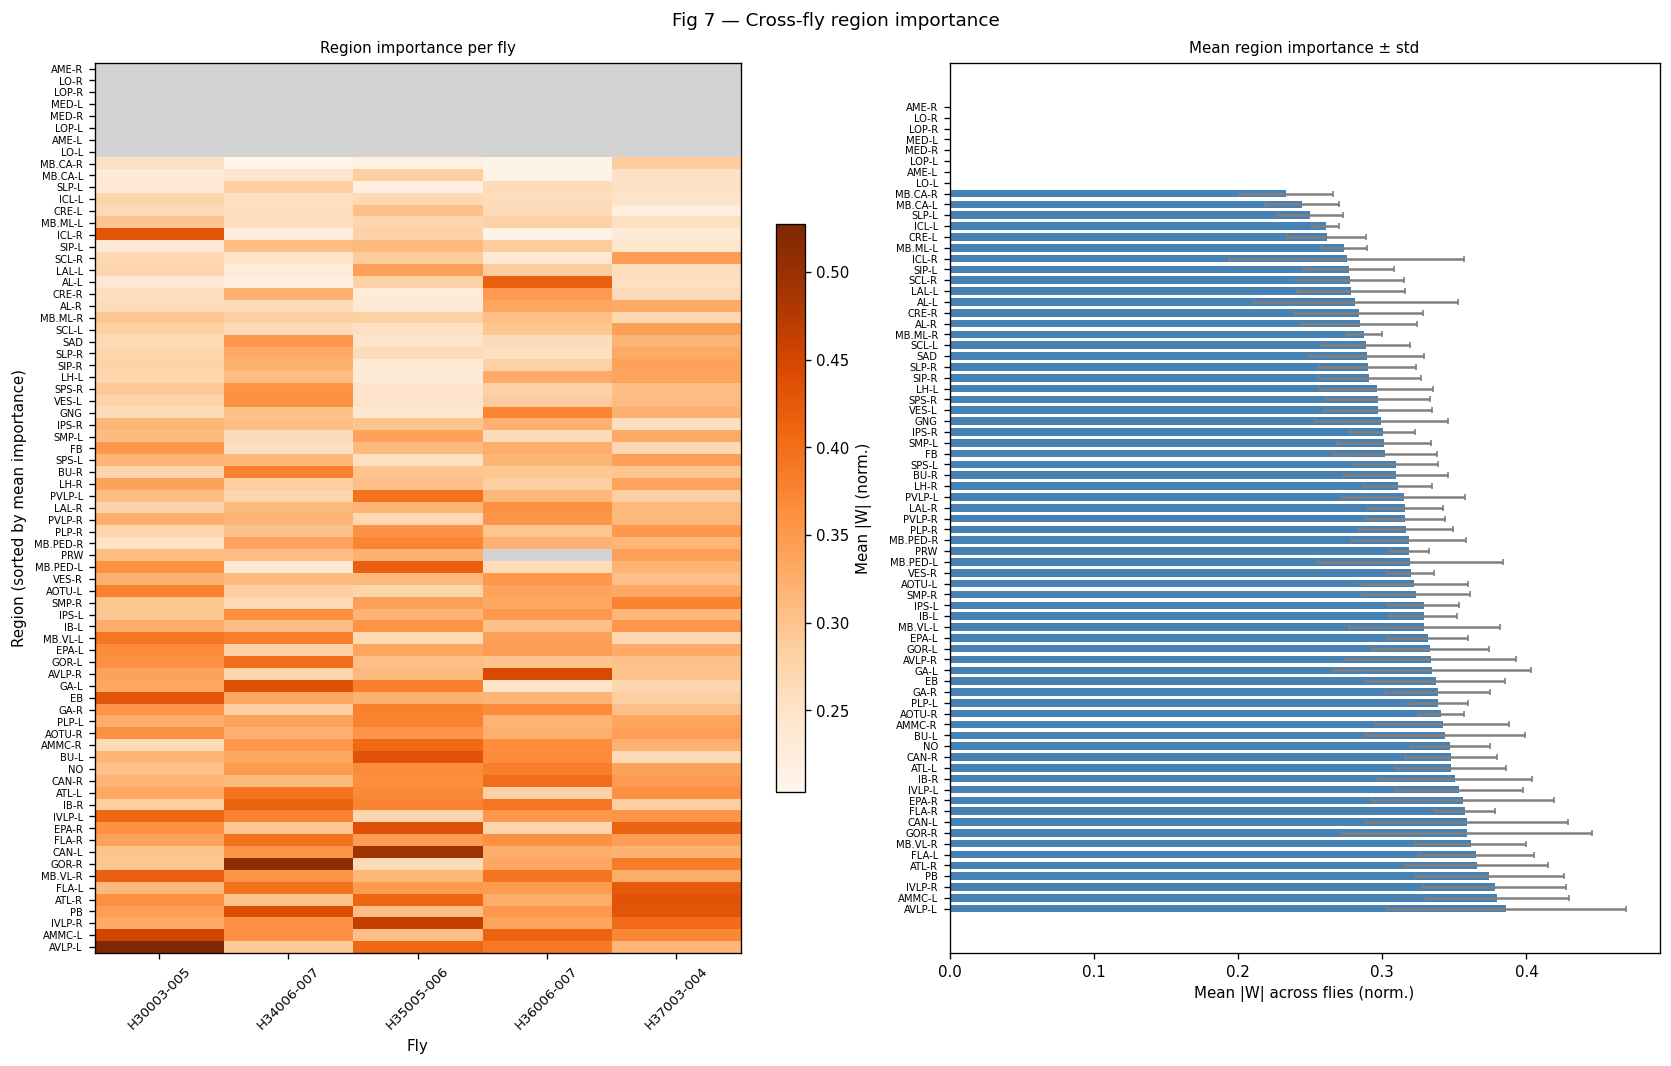

Top 10 most consistently loaded regions (present in all flies):
  AVLP-L         mean=0.386 std=0.083
  AMMC-L         mean=0.380 std=0.050
  IVLP-R         mean=0.378 std=0.050
  PB             mean=0.374 std=0.052
  ATL-R          mean=0.366 std=0.050
  FLA-L          mean=0.365 std=0.040
  MB.VL-R        mean=0.361 std=0.039
  GOR-R          mean=0.359 std=0.087
  CAN-L          mean=0.359 std=0.070
  FLA-R          mean=0.358 std=0.021


In [22]:
importance = {}   # fly_stem -> (75,) mean |W| across factors, NaN where region absent
for fly_stem in fly_stems:
    W = readout_weights[fly_stem]
    W_norm = np.abs(W) / (np.nanmax(np.abs(W), axis=0, keepdims=True) + 1e-12)
    importance[fly_stem] = np.nanmean(W_norm, axis=1)

for _s in importance:            # exclude flagged optic-lobe artifact regions from the ranking
    importance[_s][ARTIFACT_MASK] = np.nan
imp_matrix = np.stack([importance[s] for s in fly_stems], axis=1)   # (75, n_flies)
mean_importance = np.nanmean(imp_matrix, axis=1)
std_importance = np.nanstd(imp_matrix, axis=1)
n_present = np.sum(~np.isnan(imp_matrix), axis=1)

order = np.argsort(np.nan_to_num(mean_importance, nan=-1))[::-1]
sorted_names = [REGION_NAMES[i] for i in order]
sorted_imp = imp_matrix[order, :]

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
ax = axes[0]; cmap = plt.get_cmap('Oranges').copy(); cmap.set_bad('lightgrey')
im = ax.imshow(np.ma.masked_invalid(sorted_imp), aspect='auto', origin='lower', cmap=cmap)
ax.set_yticks(range(N_REGIONS)); ax.set_yticklabels(sorted_names, fontsize=6)
ax.set_xticks(range(n_flies)); ax.set_xticklabels([SHORT[s] for s in fly_stems],
                                                  fontsize=8, rotation=45)
ax.set_xlabel('Fly'); ax.set_ylabel('Region (sorted by mean importance)')
ax.set_title('Region importance per fly', fontsize=9)
plt.colorbar(im, ax=ax, label='Mean |W| (norm.)', fraction=0.04)

ax2 = axes[1]; y = range(N_REGIONS)
ax2.barh(y, np.nan_to_num(mean_importance[order]), xerr=np.nan_to_num(std_importance[order]),
         color='steelblue', height=0.7, capsize=2, ecolor='grey')
ax2.set_yticks(y); ax2.set_yticklabels(sorted_names, fontsize=6)
ax2.set_xlabel('Mean |W| across flies (norm.)'); ax2.set_title('Mean region importance ± std',
                                                              fontsize=9)
fig.suptitle('Fig 7 — Cross-fly region importance', fontsize=11)
plt.tight_layout(); plt.show()

print('Top 10 most consistently loaded regions (present in all flies):')
shown = 0
for r in order:
    if n_present[r] == n_flies:
        print(f'  {REGION_NAMES[r]:14s} mean={mean_importance[r]:.3f} std={std_importance[r]:.3f}')
        shown += 1
        if shown == 10:
            break

## Fig 7.1 — Region contribution per stimulus condition

Fig 7's importance is condition-agnostic (`|W|` across factors). Here we break region contributions
down by the **8 stimulus conditions**. For each region we take the **evoked response** of the model
reconstruction — mean over a post-stimulus window minus a pre-stimulus baseline — per condition,
averaged across flies.

- **Left:** evoked response per condition (includes the shared stimulus response — e.g. all
  odor-containing conditions light up similar regions).
- **Right:** condition-*specific* part = each region's response minus its mean across conditions,
  isolating what distinguishes the conditions.

Windows: baseline = frames [0, 140), response = [150, 750) (spans the ~frame-150 vision and ~frame-450
odor onsets). Optic-lobe artifact regions are shown but excluded from the printed top-region lists.

/tmp/ipykernel_1804241/552829492.py:15: RuntimeWarning: Mean of empty slice
  C = np.stack([np.nanmean(np.stack(percond[c], 0), 0) for c in COND_ORDER], axis=1)  # (75, 8)
/tmp/ipykernel_1804241/552829492.py:16: RuntimeWarning: Mean of empty slice
  C_spec = C - np.nanmean(C, axis=1, keepdims=True)            # condition-specific (remove shared response)


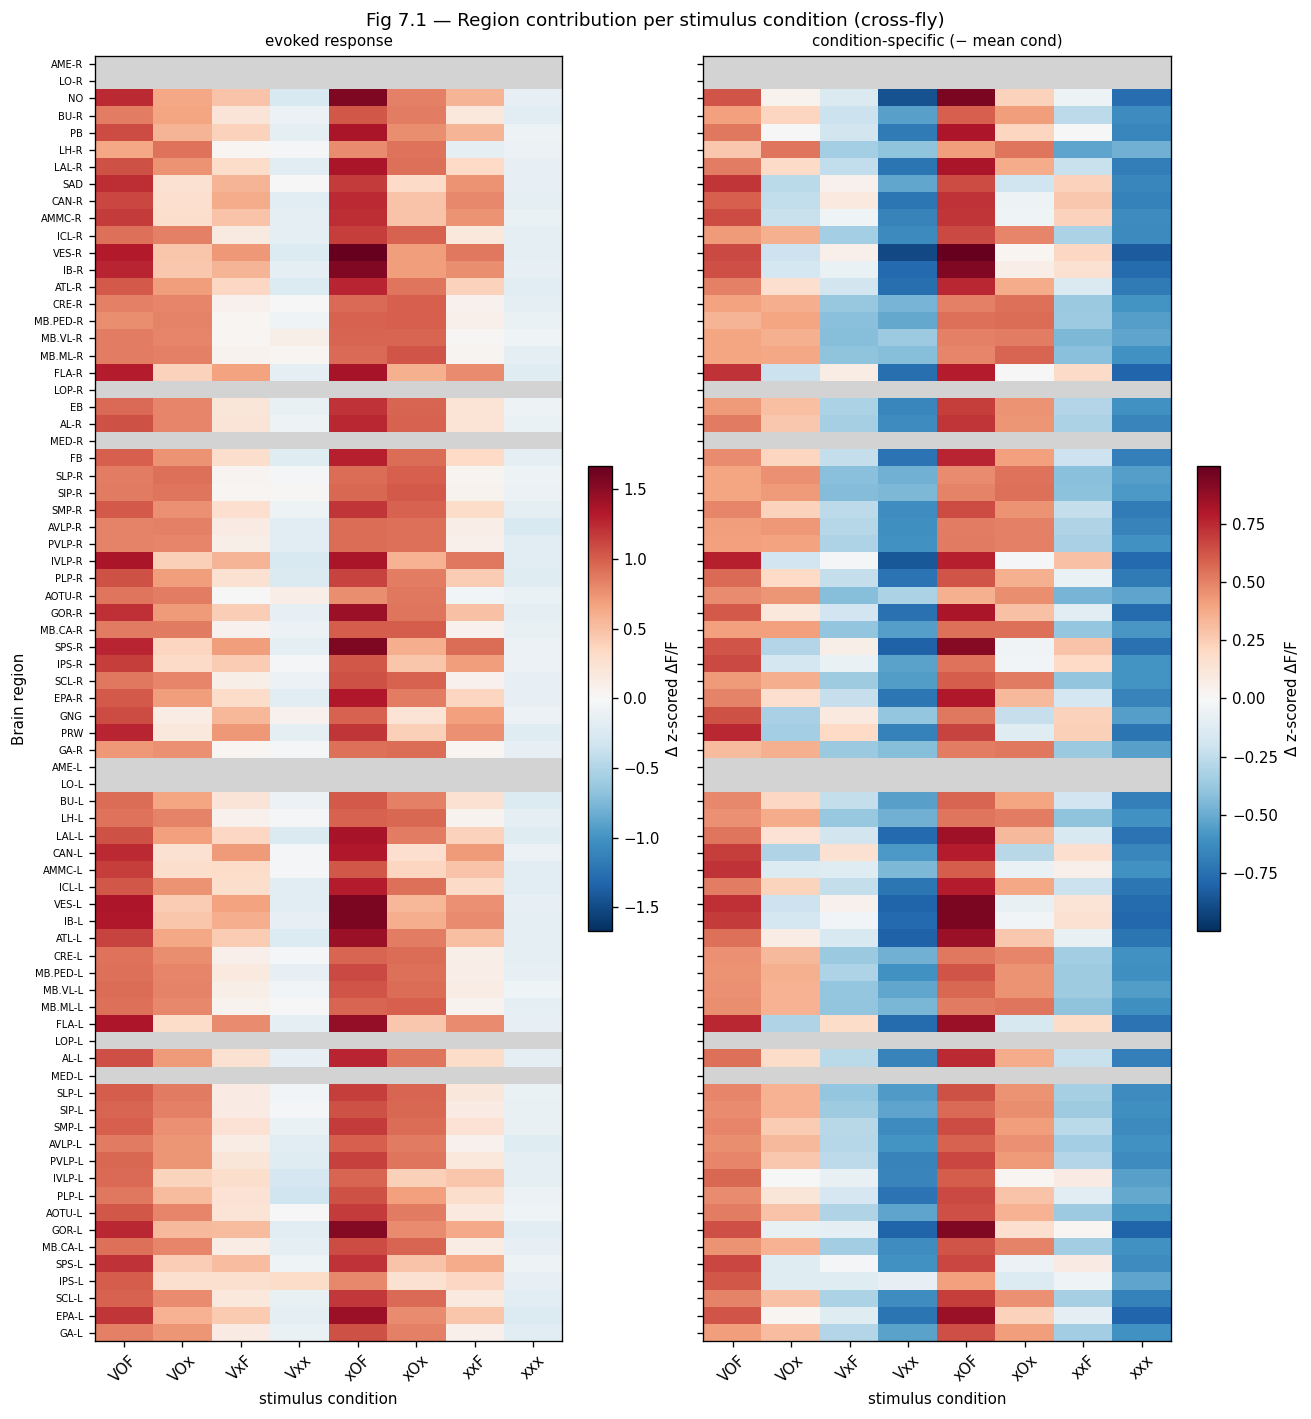

Top +regions per condition (evoked, non-artifact):
  VOF: IVLP-R(+1.36), FLA-L(+1.36), VES-L(+1.35), IB-L(+1.34), VES-R(+1.33)
  VOx: SLP-R(+0.92), LH-R(+0.91), SIP-R(+0.90), MB.CA-R(+0.87), SLP-L(+0.87)
  VxF: FLA-L(+0.79), VES-R(+0.73), PRW(+0.72), CAN-L(+0.71), SPS-R(+0.70)
  Vxx: IPS-L(+0.31), AOTU-R(+0.11), MB.VL-R(+0.10), GNG(+0.07), MB.ML-R(+0.04)
  xOF: VES-R(+1.67), IB-L(+1.58), VES-L(+1.57), SPS-R(+1.56), NO(+1.56)
  xOx: MB.ML-R(+1.05), SIP-R(+1.02), MB.CA-R(+1.01), MB.PED-R(+1.00), SLP-R(+1.00)
  xxF: SPS-R(+0.93), IVLP-R(+0.88), VES-R(+0.88), CAN-R(+0.80), IB-L(+0.79)
  xxx: MB.VL-R(-0.07), AOTU-L(-0.07), MB.VL-L(-0.08), EB(-0.09), SLP-R(-0.09)


In [23]:
BASE_WIN, RESP_WIN = slice(0, 140), slice(150, 750)   # pre-stimulus baseline / response window
COND_ORDER = ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']

cond = {s: cond_for(s) for s in fly_stems}   # baseline trials [0,9] dropped to match 16-trial h5s

# per-condition evoked response per region, lifted to canonical frame and averaged across flies
percond = {c: [] for c in COND_ORDER}
for s in fly_stems:
    O = fly_data[s]['output_params']                         # (trials, time, n_reg)
    for c in COND_ORDER:
        m = cond[s] == c
        if m.any():
            ev = O[m][:, RESP_WIN, :].mean((0, 1)) - O[m][:, BASE_WIN, :].mean((0, 1))
            percond[c].append(to_canon(ev, s))
C = np.stack([np.nanmean(np.stack(percond[c], 0), 0) for c in COND_ORDER], axis=1)  # (75, 8)
C_spec = C - np.nanmean(C, axis=1, keepdims=True)            # condition-specific (remove shared response)

fig, axes = plt.subplots(1, 2, figsize=(11, 12), sharey=True)
cmap = plt.get_cmap('RdBu_r').copy(); cmap.set_bad('lightgrey')
for ax, M, title in [(axes[0], C, 'evoked response'),
                     (axes[1], C_spec, 'condition-specific (− mean cond)')]:
    vmax = np.nanmax(np.abs(M))
    im = ax.imshow(np.ma.masked_invalid(M), aspect='auto', cmap=cmap, vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(COND_ORDER))); ax.set_xticklabels(COND_ORDER, rotation=45)
    ax.set_title(title, fontsize=9); ax.set_xlabel('stimulus condition')
    fig.colorbar(im, ax=ax, fraction=0.045, label='Δ z-scored ΔF/F')
axes[0].set_yticks(range(N_REGIONS)); axes[0].set_yticklabels(REGION_NAMES, fontsize=6)
axes[0].set_ylabel('Brain region')
fig.suptitle('Fig 7.1 — Region contribution per stimulus condition (cross-fly)', fontsize=11)
plt.tight_layout(); plt.show()

print('Top +regions per condition (evoked, non-artifact):')
for j, c in enumerate(COND_ORDER):
    v = C[:, j].copy(); v[ARTIFACT_MASK] = np.nan
    top = np.argsort(np.nan_to_num(v, nan=-1e9))[::-1][:5]
    print(f'  {c}: ' + ', '.join(f'{REGION_NAMES[r]}({v[r]:+.2f})' for r in top))

## Fig 7.2 — Region contributions on the JFRC brain volume (dorsal)

Python port of `kcRIDGE_projectBetasToVolume`: each region's evoked contribution (`C` from Fig 7.1)
is painted into its voxels in the 75-region JFRC mask and **dorsal** max-|·| projected (lateral/coronal
dropped). The projection is rotated **90° left** into the standard fly-brain landscape orientation.
All 8 conditions, shared colour scale. Requires `nibabel` + the mask; voxel→region lookup cached to
`VOX_CACHE`. Assumes the mask's 4th-dim region order matches `REGION_NAMES`.

voxel-region volume (512, 256, 44), regions present: 75/75


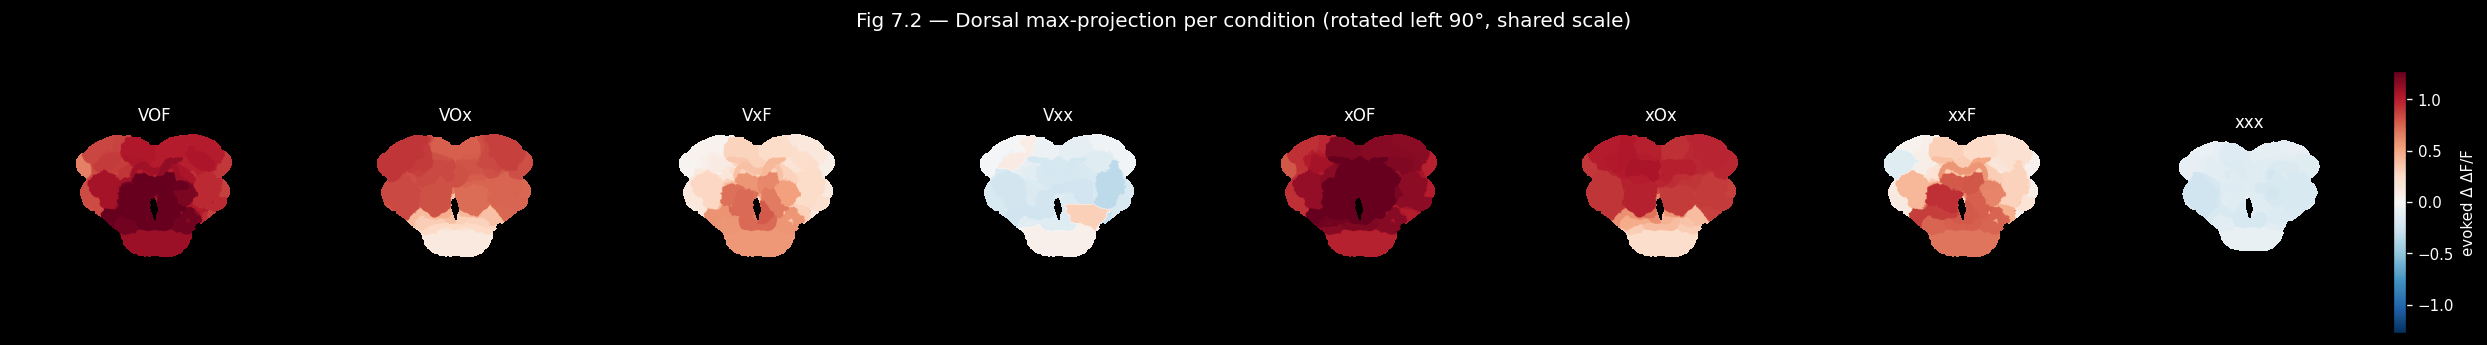

In [24]:
import os
JFRC_MASK = '/home/kyc_hpz8/Documents/regions-analysis/JFRCMask_separate_75regions.nii'
VOX_CACHE = '/home/kyc_hpz8/Documents/regions-analysis/voxelRegion_ds2_75.npy'
DS = 2          # spatial downsample (X, Y)
LFMRATE = 30    # Hz (for time labels in Fig 7.3)
try:
    import nibabel as nib
    if os.path.exists(VOX_CACHE):
        vox = np.load(VOX_CACHE)
    else:
        _img = nib.load(JFRC_MASK, mmap=True)
        _v = np.zeros(_img.shape[:3], np.uint8)
        for r in range(_img.shape[3]):
            _v[np.asarray(_img.dataobj[..., r]) > 0] = r + 1
        vox = _v[::DS, ::DS, :]; np.save(VOX_CACHE, vox)
    print(f'voxel-region volume {vox.shape}, regions present: {len(np.unique(vox)) - 1}/{N_REGIONS}')

    def _dorsal(V):
        idx = np.argmax(np.abs(np.nan_to_num(V)), axis=2)
        p = np.take_along_axis(V, np.expand_dims(idx, 2), 2).squeeze(2)
        p[np.all(np.isnan(V), axis=2)] = np.nan
        return np.rot90(np.rot90(p.T, -1), 1)     # MATLAB dorsal orientation, then rotated 90° left
    def _valvol(v):
        vv = np.full(vox.shape, np.nan, np.float32); m = vox > 0
        vv[m] = v[vox[m].astype(int) - 1]; return vv
    bcmap = plt.get_cmap('RdBu_r').copy(); bcmap.set_bad('k')

    fig, axes = plt.subplots(1, len(COND_ORDER), figsize=(2.6 * len(COND_ORDER), 3.0))
    fig.patch.set_facecolor('k'); cl = np.nanpercentile(np.abs(C), 95)
    for ax, c in zip(axes, COND_ORDER):
        ax.set_facecolor('k'); ax.set_xticks([]); ax.set_yticks([])
        im = ax.imshow(np.ma.masked_invalid(_dorsal(_valvol(C[:, COND_ORDER.index(c)]))),
                       cmap=bcmap, vmin=-cl, vmax=cl)
        ax.set_title(c, color='w', fontsize=10)
    cb = fig.colorbar(im, ax=axes[-1], fraction=0.046); cb.ax.tick_params(colors='w')
    cb.set_label('evoked Δ ΔF/F', color='w')
    fig.suptitle('Fig 7.2 — Dorsal max-projection per condition (rotated left 90°, shared scale)',
                 color='w', fontsize=12)
    plt.tight_layout(); plt.show()
except (ImportError, FileNotFoundError) as e:
    print('Brain-volume projection skipped:', repr(e), '\n(need nibabel + the JFRC mask file)')

## Fig 7.3 — Time-evolving dorsal projection

Instead of one evoked scalar per region, project the **condition-mean response at several timepoints**
across the trial (each a ±0.5 s window, baseline-subtracted), for the odor / walk / vision single-on
conditions — the `nSnapshots` idea from the MATLAB. Shows how each modality's spatial response builds
and decays. Dorsal only, rotated left 90°; colour scale is per row (per condition) so the temporal
dynamics are visible. Times are `frame / LFMRATE` seconds.

/tmp/ipykernel_1804241/3037866744.py:13: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(vals, 0), 0)


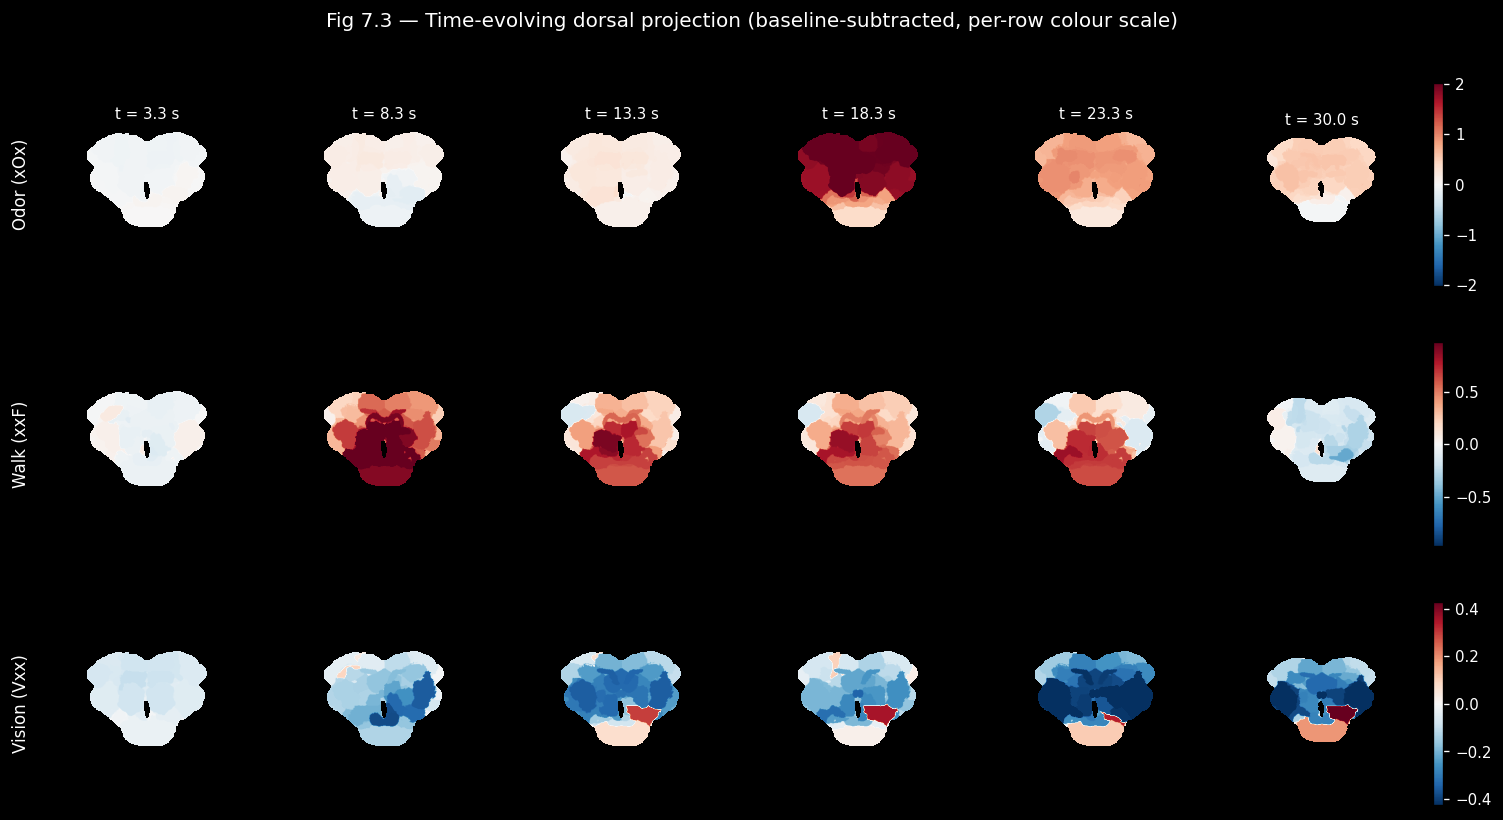

In [25]:
try:
    SNAP_FRAMES = [100, 250, 400, 550, 700, 900]; SNAP_W = 15   # ±0.5 s windows
    def _snap(c, fr):
        vals = []
        for s in fly_stems:
            m = cond[s] == c
            if not m.any():
                continue
            O = fly_data[s]['output_params']
            base = O[m][:, BASE_WIN, :].mean((0, 1))
            resp = O[m][:, max(0, fr - SNAP_W):fr + SNAP_W, :].mean((0, 1)) - base
            vals.append(to_canon(resp, s))
        return np.nanmean(np.stack(vals, 0), 0)

    rows = [('xOx', 'Odor (xOx)'), ('xxF', 'Walk (xxF)'), ('Vxx', 'Vision (Vxx)')]
    fig, axes = plt.subplots(len(rows), len(SNAP_FRAMES),
                             figsize=(2.1 * len(SNAP_FRAMES), 2.4 * len(rows)))
    fig.patch.set_facecolor('k')
    for i, (c, ttl) in enumerate(rows):
        snaps = [_snap(c, fr) for fr in SNAP_FRAMES]
        allv = np.abs(np.concatenate([s[~np.isnan(s)] for s in snaps]))
        cl = np.percentile(allv[allv > 0], 97) if (allv > 0).any() else 1e-3
        for j, (fr, sv) in enumerate(zip(SNAP_FRAMES, snaps)):
            ax = axes[i, j]; ax.set_facecolor('k'); ax.set_xticks([]); ax.set_yticks([])
            im = ax.imshow(np.ma.masked_invalid(_dorsal(_valvol(sv))), cmap=bcmap, vmin=-cl, vmax=cl)
            if i == 0: ax.set_title(f't = {fr / LFMRATE:.1f} s', color='w', fontsize=9)
            if j == 0: ax.set_ylabel(ttl, color='w', fontsize=10)
        cb = fig.colorbar(im, ax=axes[i, -1], fraction=0.046); cb.ax.tick_params(colors='w')
    fig.suptitle('Fig 7.3 — Time-evolving dorsal projection (baseline-subtracted, per-row colour scale)',
                 color='w', fontsize=12)
    plt.tight_layout(); plt.show()
except (ImportError, FileNotFoundError, NameError) as e:
    print('Time-evolving projection skipped:', repr(e))

## Fig 7.4 — Readout-weight importance on the brain

Fig 7's region **importance** (mean |W| across factors — how strongly the latent factors drive each
region in the reconstruction) projected onto the JFRC volume (dorsal, rotated left 90°). This is
**condition-agnostic** (the readout weights don't depend on stimulus), so it's a single map per fly
plus the cross-fly mean — a spatial view of which regions the shared factor space reconstructs most
strongly. Contrast with 7.2/7.3, which show stimulus *responses*. Optic-lobe artifacts greyed.

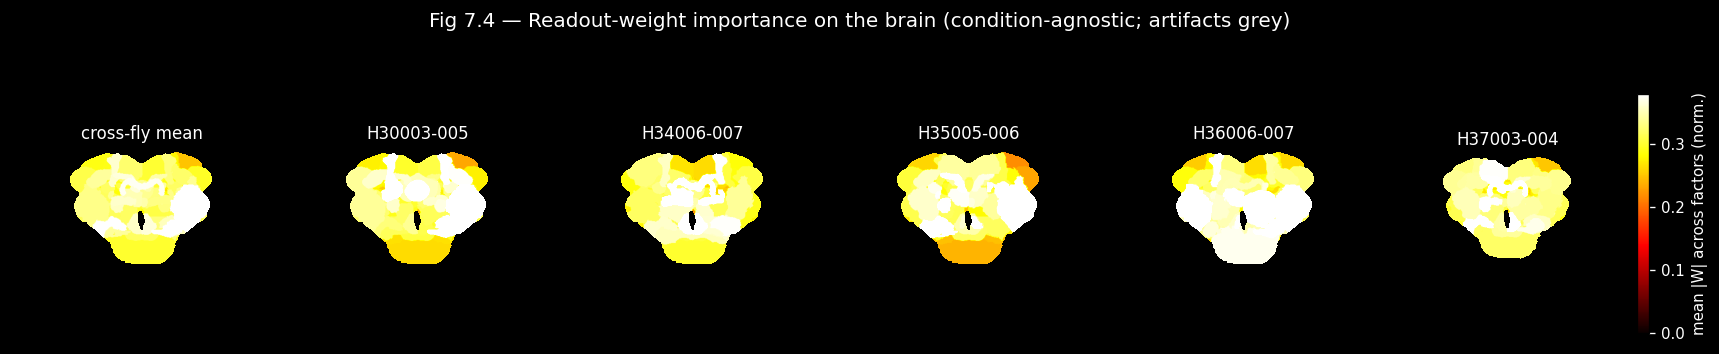

In [26]:
# projects Fig 7's readout-weight importance (mean |W|) onto the brain; needs Fig 7.2 helpers + Fig 7
try:
    imp_cmap = plt.get_cmap('hot').copy(); imp_cmap.set_bad('k')   # importance >= 0 -> sequential
    maps = [('cross-fly mean', mean_importance)] + [(SHORT[s], importance[s]) for s in fly_stems]
    fig, axes = plt.subplots(1, len(maps), figsize=(2.4 * len(maps), 3.2)); fig.patch.set_facecolor('k')
    vmax = np.nanpercentile(mean_importance, 98)
    for ax, (lbl, v) in zip(axes, maps):
        ax.set_facecolor('k'); ax.set_xticks([]); ax.set_yticks([])
        im = ax.imshow(np.ma.masked_invalid(_dorsal(_valvol(v))), cmap=imp_cmap, vmin=0, vmax=vmax)
        ax.set_title(lbl, color='w', fontsize=10)
    cb = fig.colorbar(im, ax=axes[-1], fraction=0.046); cb.ax.tick_params(colors='w')
    cb.set_label('mean |W| across factors (norm.)', color='w')
    fig.suptitle('Fig 7.4 — Readout-weight importance on the brain '
                 '(condition-agnostic; artifacts grey)', color='w', fontsize=12)
    plt.tight_layout(); plt.show()
except NameError as e:
    print('Fig 7.4 needs Fig 7 (importance) and Fig 7.2 (vox/_dorsal/_valvol) to have run:', repr(e))

> ⚠️ **Caveat — this is decoding *geometry*, not response anatomy.** The region loadings
> `W_fly @ w_mod` correlate ~0 with the actual evoked responses (odor +0.04, walk −0.01, vision −0.18)
> and are dominated by the single highest-readout-weight region (**PRW**, #1 of 75 in |W|), so the
> top regions here are not reliable anatomy. For 'which regions respond' use Fig 7.1/7.2 (evoked); for
> modality **interactions** use Fig 8.1 below. Fig 8's real value is the *decodability* (nb4 AUCs).

## Fig 8 — Which regions drive the odor / walk / vision axes?

Factor indices are rotation-ambiguous, so reading region loadings off individual factors is not
portable. Instead we **rotate the latent space to the named stimulus directions** recovered in
`4_decode_stimulus_kcEXP00H.ipynb`: fit the per-channel logistic decoder on pooled factors to get a
unit weight vector `w_mod` (50-D) for odor, walk, and vision, then map it into region space through
each fly's readout, `loading_mod = W_fly @ w_mod` (n_regions,). This is the region pattern whose
reconstructed activity moves most along the stimulus-decoding axis — i.e. **where in the brain each
stimulus is represented**. Loadings are lifted to the canonical 75-region frame and averaged across
flies (nanmean).

> Optic-lobe artifact regions (`ARTIFACT_REGIONS`, set by `ARTIFACT_BASES`) are **excluded** from the rankings/hubs below and shown grey in the heatmaps.

/tmp/ipykernel_1804241/794802547.py:34: RuntimeWarning: Mean of empty slice
  loading[mod] = np.nanmean(per_fly, axis=0)        # (75,) signed


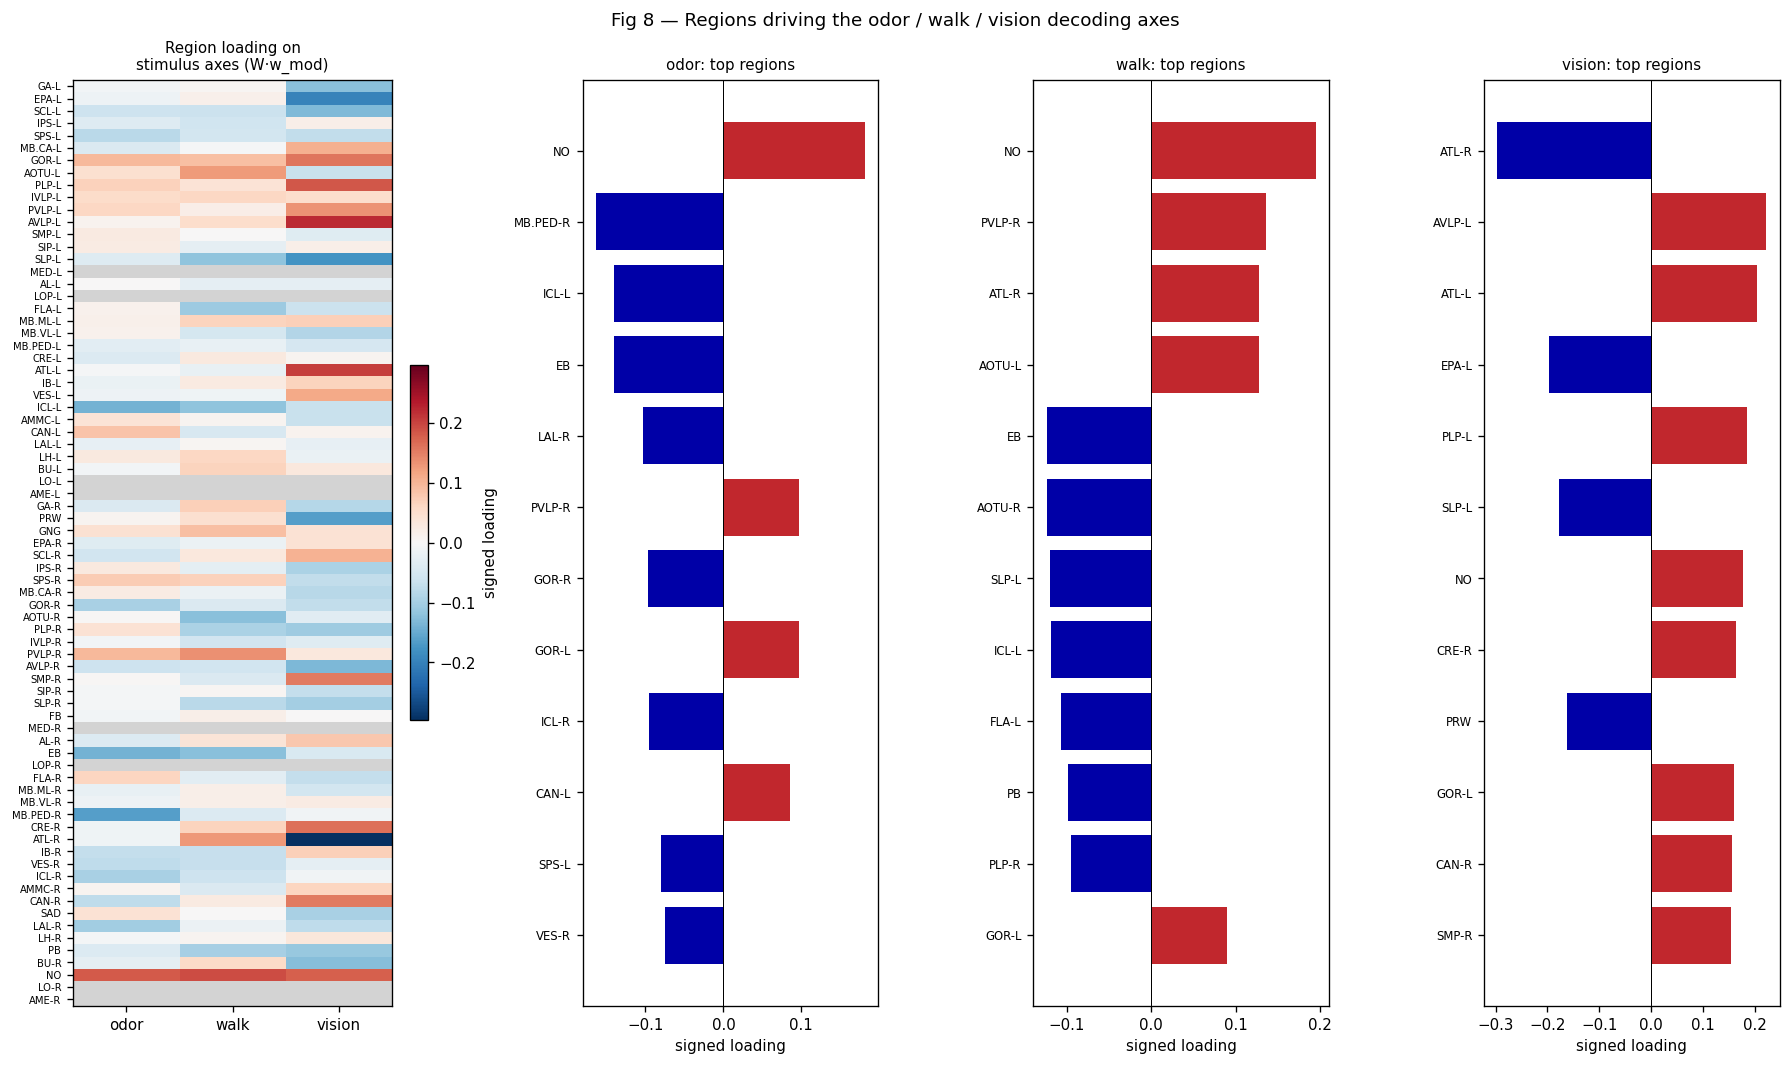

Top regions per stimulus axis (signed W·w_mod, mean across flies):
  odor  : NO(+0.18), MB.PED-R(-0.16), ICL-L(-0.14), EB(-0.14), LAL-R(-0.10), PVLP-R(+0.10)
  walk  : NO(+0.19), PVLP-R(+0.14), ATL-R(+0.13), AOTU-L(+0.13), EB(-0.12), AOTU-R(-0.12)
  vision: ATL-R(-0.30), AVLP-L(+0.22), ATL-L(+0.20), EPA-L(-0.20), PLP-L(+0.18), SLP-L(-0.18)


In [27]:
from sklearn.linear_model import LogisticRegression

MODALITIES = {'odor': ('odor_state_frame', 'odor_trial_bool'),
              'walk': ('fw_state_frame',   'fw_trial_bool'),
              'vision': ('vis_state_frame', 'vis_trial_bool')}

# Whole-trial binary stimulus targets per fly, aligned to the original-order factors in fly_data
def stim_targets(fly_stem):
    ds = ds_by_flyid[[k for k in ds_by_flyid if k in fly_stem][0]]
    nt, n_time = fly_data[fly_stem]['factors'].shape[:2]
    out = {}
    for mod, (sv, bv) in MODALITIES.items():
        state = np.asarray(ds[sv].values).reshape(-1)
        tb = np.asarray(ds[bv].values).reshape(-1)
        tb = drop_baseline_trials(tb, nt)   # realign 18-trial .nc labels to the 16-trial h5s
        out[mod] = (tb[:, None].astype(float) * (state[None, :] > 0)).astype(int)
        assert out[mod].shape == (nt, n_time), (fly_stem, mod, out[mod].shape, (nt, n_time))
    return out

targets = {s: stim_targets(s) for s in fly_stems}

# Pooled decoder direction per modality (shared 50-D factor space across flies), unit-normalised
w_mod = {}
for mod in MODALITIES:
    X = np.concatenate([fly_data[s]['factors'].reshape(-1, n_fac) for s in fly_stems], 0)
    y = np.concatenate([targets[s][mod].reshape(-1) for s in fly_stems], 0)
    w = LogisticRegression(class_weight='balanced', max_iter=1000).fit(X, y).coef_.reshape(-1)
    w_mod[mod] = w / (np.linalg.norm(w) + 1e-12)

# Map each decoding axis into region space per fly, lift to canonical 75, average across flies
loading = {}
for mod in MODALITIES:
    per_fly = np.stack([to_canon(readout_W[s] @ w_mod[mod], s) for s in fly_stems], 0)
    loading[mod] = np.nanmean(per_fly, axis=0)        # (75,) signed

for _m in loading:               # exclude flagged optic-lobe artifact regions (Figs 8-10)
    loading[_m][ARTIFACT_MASK] = np.nan
mods = list(MODALITIES)
L = np.stack([loading[m] for m in mods], axis=1)      # (75, 3)

fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(1, 4, width_ratios=[1.2, 1, 1, 1])
axh = fig.add_subplot(gs[0, 0])
vmax = np.nanmax(np.abs(L)); cmap = plt.get_cmap('RdBu_r').copy(); cmap.set_bad('lightgrey')
im = axh.imshow(np.ma.masked_invalid(L), aspect='auto', origin='lower',
                cmap=cmap, vmin=-vmax, vmax=vmax)
axh.set_xticks(range(3)); axh.set_xticklabels(mods)
axh.set_yticks(range(N_REGIONS)); axh.set_yticklabels(REGION_NAMES, fontsize=6)
axh.set_title('Region loading on\nstimulus axes (W·w_mod)', fontsize=9)
fig.colorbar(im, ax=axh, fraction=0.05, label='signed loading')

for k, mod in enumerate(mods):
    ax = fig.add_subplot(gs[0, k + 1])
    v = np.nan_to_num(loading[mod])
    top = np.argsort(np.abs(v))[::-1][:12][::-1]
    ax.barh(range(len(top)), v[top],
            color=['#c1272d' if v[i] > 0 else '#0000a7' for i in top])
    ax.set_yticks(range(len(top))); ax.set_yticklabels([REGION_NAMES[i] for i in top], fontsize=7)
    ax.axvline(0, color='k', lw=0.6); ax.set_title(f'{mod}: top regions', fontsize=9)
    ax.set_xlabel('signed loading')
fig.suptitle('Fig 8 — Regions driving the odor / walk / vision decoding axes', fontsize=11)
plt.tight_layout(); plt.show()

print('Top regions per stimulus axis (signed W·w_mod, mean across flies):')
for mod in mods:
    v = np.nan_to_num(loading[mod]); o = np.argsort(np.abs(v))[::-1][:6]
    print(f'  {mod:6s}: ' + ', '.join(f'{REGION_NAMES[r]}({v[r]:+.2f})' for r in o))

## Fig 8.1 — Modality interactions (do the effects add up?)

The per-region evoked responses (`C` from Fig 7.1) form a full **2×2×2 factorial** (V, O, F). This
isolates **interactions** — whether one modality's effect depends on another — which the per-condition
Fig 7 doesn't separate. This is the encoding/interaction question (distinct from Fig 8's decoding axes).

- **(a) Additivity scatter:** for each modality pair, each region's effect of modality B when A is
  **OFF** (x) vs **ON** (y). On the red diagonal ⇒ additive (B's effect independent of A); off-diagonal
  ⇒ interaction. This generalises your `xOF − xOx` vs `xxF − xxx` (walk effect with / without odor).
- **(b) Factorial contrasts per region:** main effects (V, O, F) and interactions (V×O, V×F, O×F,
  V×O×F), ±1 coding. Optic-lobe artifacts excluded from the scatters / printed lists.

Finding: **walk×odor is superadditive** (points above the diagonal — walk response amplified by odor);
vision combines **additively** with both. Top O×F-interaction regions: mechanosensory/motor (AMMC,
SAD, VES, IPS, CAN, GNG).

/tmp/ipykernel_1804241/781386439.py:13: RuntimeWarning: Mean of empty slice
  return (np.nanmean([C[:, CO.index(c)] for c in on], 0)
/tmp/ipykernel_1804241/781386439.py:14: RuntimeWarning: Mean of empty slice
  - np.nanmean([C[:, CO.index(c)] for c in off], 0))


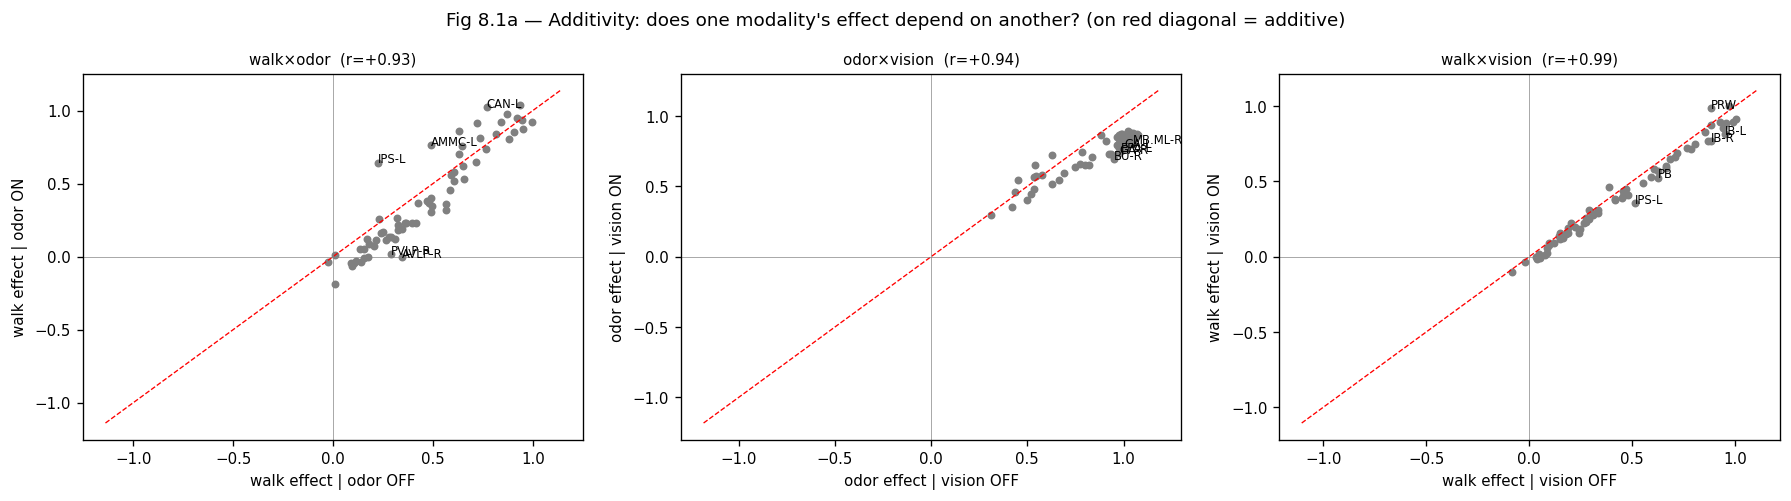

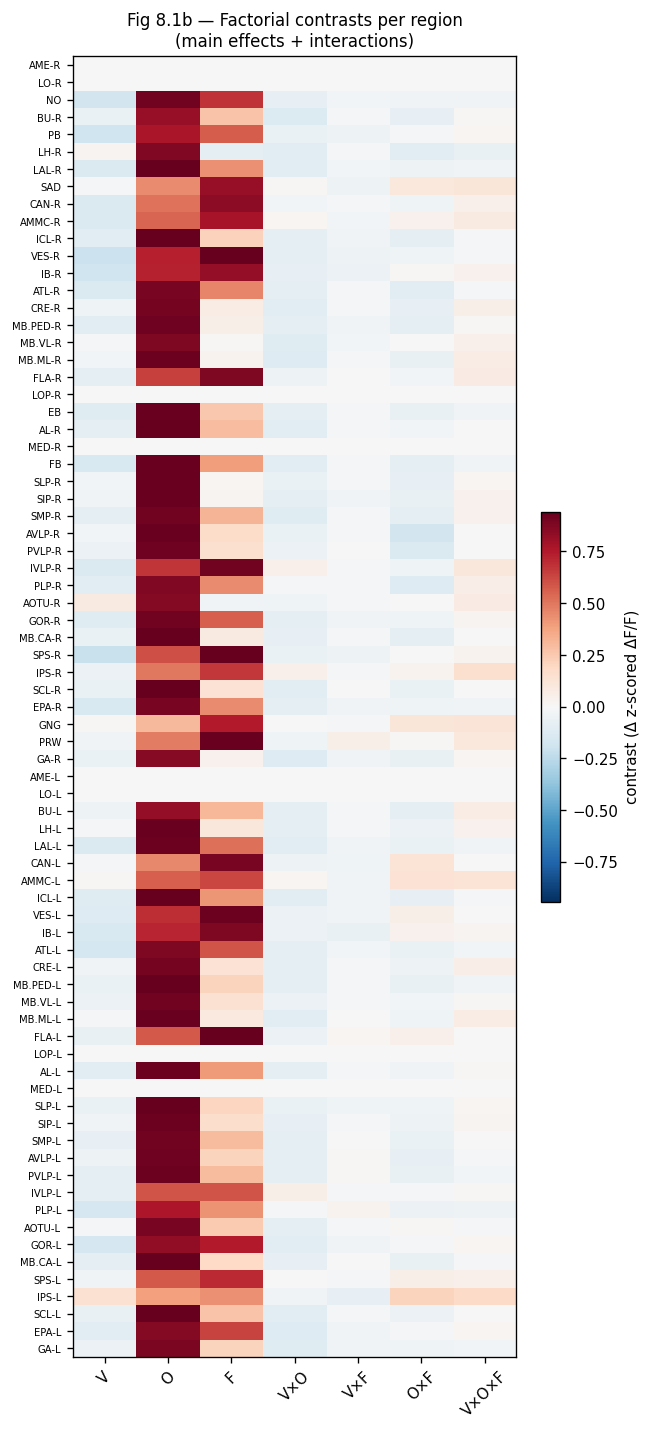

Mean |contrast| and top non-artifact regions per term:
  V      |0.076|  SPS-R(-0.21), VES-R(-0.20), IB-R(-0.19), PB(-0.18), NO(-0.18)
  O      |0.723|  AL-R(+0.97), SCL-L(+0.97), ICL-R(+0.96), MB.CA-R(+0.96), SLP-L(+0.96)
  F      |0.379|  FLA-L(+0.99), VES-R(+0.96), SPS-R(+0.94), PRW(+0.93), VES-L(+0.92)
  V×O    |0.066|  BU-R(-0.13), MB.ML-R(-0.12), GA-R(-0.12), EPA-L(-0.12), GA-L(-0.12)
  V×F    |0.022|  IPS-L(-0.08), IB-L(-0.07), IB-R(-0.06), PRW(+0.05), PB(-0.05)
  O×F    |0.055|  IPS-L(+0.21), AVLP-R(-0.17), AMMC-L(+0.14), PVLP-R(-0.14), CAN-L(+0.13)
  V×O×F  |0.036|  IPS-L(+0.18), IPS-R(+0.15), AMMC-L(+0.13), GNG(+0.12), SAD(+0.11)


In [28]:
CO = COND_ORDER
code = {c: (1 if c[0] == 'V' else -1, 1 if c[1] == 'O' else -1, 1 if c[2] == 'F' else -1) for c in CO}
def contrast(sel):
    w = np.array([np.prod([code[c][k] for k in sel]) for c in CO])
    return np.nansum(C * w[None, :], 1) / 4.0
terms = {'V': (0,), 'O': (1,), 'F': (2,), 'V×O': (0, 1), 'V×F': (0, 2), 'O×F': (1, 2), 'V×O×F': (0, 1, 2)}
T = np.stack([contrast(s) for s in terms.values()], 1)   # (75, 7)
IDX = {'V': 0, 'O': 1, 'F': 2}
def split_effect(b, a):     # effect of B split by A off/on, averaged over the 3rd factor
    def eff(av):
        on = [c for c in CO if code[c][IDX[a]] == av and code[c][IDX[b]] == 1]
        off = [c for c in CO if code[c][IDX[a]] == av and code[c][IDX[b]] == -1]
        return (np.nanmean([C[:, CO.index(c)] for c in on], 0)
                - np.nanmean([C[:, CO.index(c)] for c in off], 0))
    return eff(-1), eff(1)

# (a) additivity scatters
pairs = [('O', 'F', 'odor', 'walk'), ('V', 'O', 'vision', 'odor'), ('V', 'F', 'vision', 'walk')]
fig = plt.figure(figsize=(15, 4.2))
for k, (a, b, an, bn) in enumerate(pairs):
    ax = fig.add_subplot(1, 3, k + 1); xoff, xon = split_effect(b, a)
    m = ~(np.isnan(xoff) | np.isnan(xon)) & ~ARTIFACT_MASK
    ax.scatter(xoff[m], xon[m], s=14, c='grey')
    lim = np.nanmax(np.abs(np.concatenate([xoff[m], xon[m]]))) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=0.8)
    ax.axhline(0, color='grey', lw=0.4); ax.axvline(0, color='grey', lw=0.4)
    dev = np.abs(xon - xoff); dev[~m] = np.nan
    for i in np.argsort(np.nan_to_num(dev))[::-1][:5]:
        ax.annotate(REGION_NAMES[i], (xoff[i], xon[i]), fontsize=7)
    rr = np.corrcoef(xoff[m], xon[m])[0, 1]
    ax.set_xlabel(f'{bn} effect | {an} OFF'); ax.set_ylabel(f'{bn} effect | {an} ON')
    ax.set_title(f'{bn}×{an}  (r={rr:+.2f})', fontsize=9)
fig.suptitle("Fig 8.1a — Additivity: does one modality's effect depend on another? "
             "(on red diagonal = additive)", fontsize=11)
plt.tight_layout(); plt.show()

# (b) factorial contrast heatmap
fig, ax = plt.subplots(figsize=(5.5, 12)); cmap = plt.get_cmap('RdBu_r').copy(); cmap.set_bad('lightgrey')
vmax = np.nanpercentile(np.abs(T), 98)
im = ax.imshow(np.ma.masked_invalid(T), aspect='auto', cmap=cmap, vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(terms))); ax.set_xticklabels(list(terms), rotation=45)
ax.set_yticks(range(N_REGIONS)); ax.set_yticklabels(REGION_NAMES, fontsize=6)
ax.set_title('Fig 8.1b — Factorial contrasts per region\n(main effects + interactions)', fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.04, label='contrast (Δ z-scored ΔF/F)')
plt.tight_layout(); plt.show()

print('Mean |contrast| and top non-artifact regions per term:')
for t, sel in terms.items():
    v = contrast(sel).copy(); mag = np.nanmean(np.abs(v)); v[ARTIFACT_MASK] = np.nan
    top = np.argsort(np.nan_to_num(np.abs(v)))[::-1][:5]
    print(f'  {t:6s} |{mag:.3f}|  ' + ', '.join(f'{REGION_NAMES[i]}({v[i]:+.2f})' for i in top))

## Fig 9 — Multimodal regions: which regions contribute to multiple stimulus axes?

Builds on Fig 8. A region **significantly contributes** to a modality if its `|loading|` is in the
**top tertile** across present regions for that axis. We then count, per region, how many of the
three axes (odor / walk / vision) it contributes to, and list the pairwise and three-way overlaps —
candidate **multimodal / integrative** regions vs modality-specific ones.

> **Caveat — axis non-orthogonality.** The three decoding directions are not orthogonal, so part of
> any overlap is *shared axis variance*, not true integration. The cell prints both the decoder-axis
> cosine similarities and the region-loading correlations. In this run **odor–walk is essentially
> independent** (overlap trustworthy), while **odor–vision is the most correlated** (overlap partly
> trivial — and the outlier region **PRW** sits in that pair). Read odor∩walk overlaps as the
> strongest evidence of genuine multimodality.

> Optic-lobe artifact regions (`ARTIFACT_REGIONS`, set by `ARTIFACT_BASES`) are **excluded** from the rankings/hubs below and shown grey in the heatmaps.

Decoder-axis cosine (factor space) | region-loading correlation:
  odor-walk: cos=+0.11  r_load=+0.53
  odor-vision: cos=+0.20  r_load=+0.22
  walk-vision: cos=+0.39  r_load=+0.27

Trimodal (all 3 axes): ['NO', 'GOR-L', 'SCL-L']
  odor&walk: ['NO', 'VES-R', 'IB-R', 'EB', 'PVLP-R', 'SPS-R', 'ICL-L', 'GOR-L', 'SCL-L']
  odor&vision: ['NO', 'CAN-R', 'AVLP-R', 'SCL-R', 'PVLP-L', 'PLP-L', 'GOR-L', 'SCL-L']
  walk&vision: ['NO', 'PB', 'ATL-R', 'CRE-R', 'PLP-R', 'SLP-L', 'GOR-L', 'SCL-L']


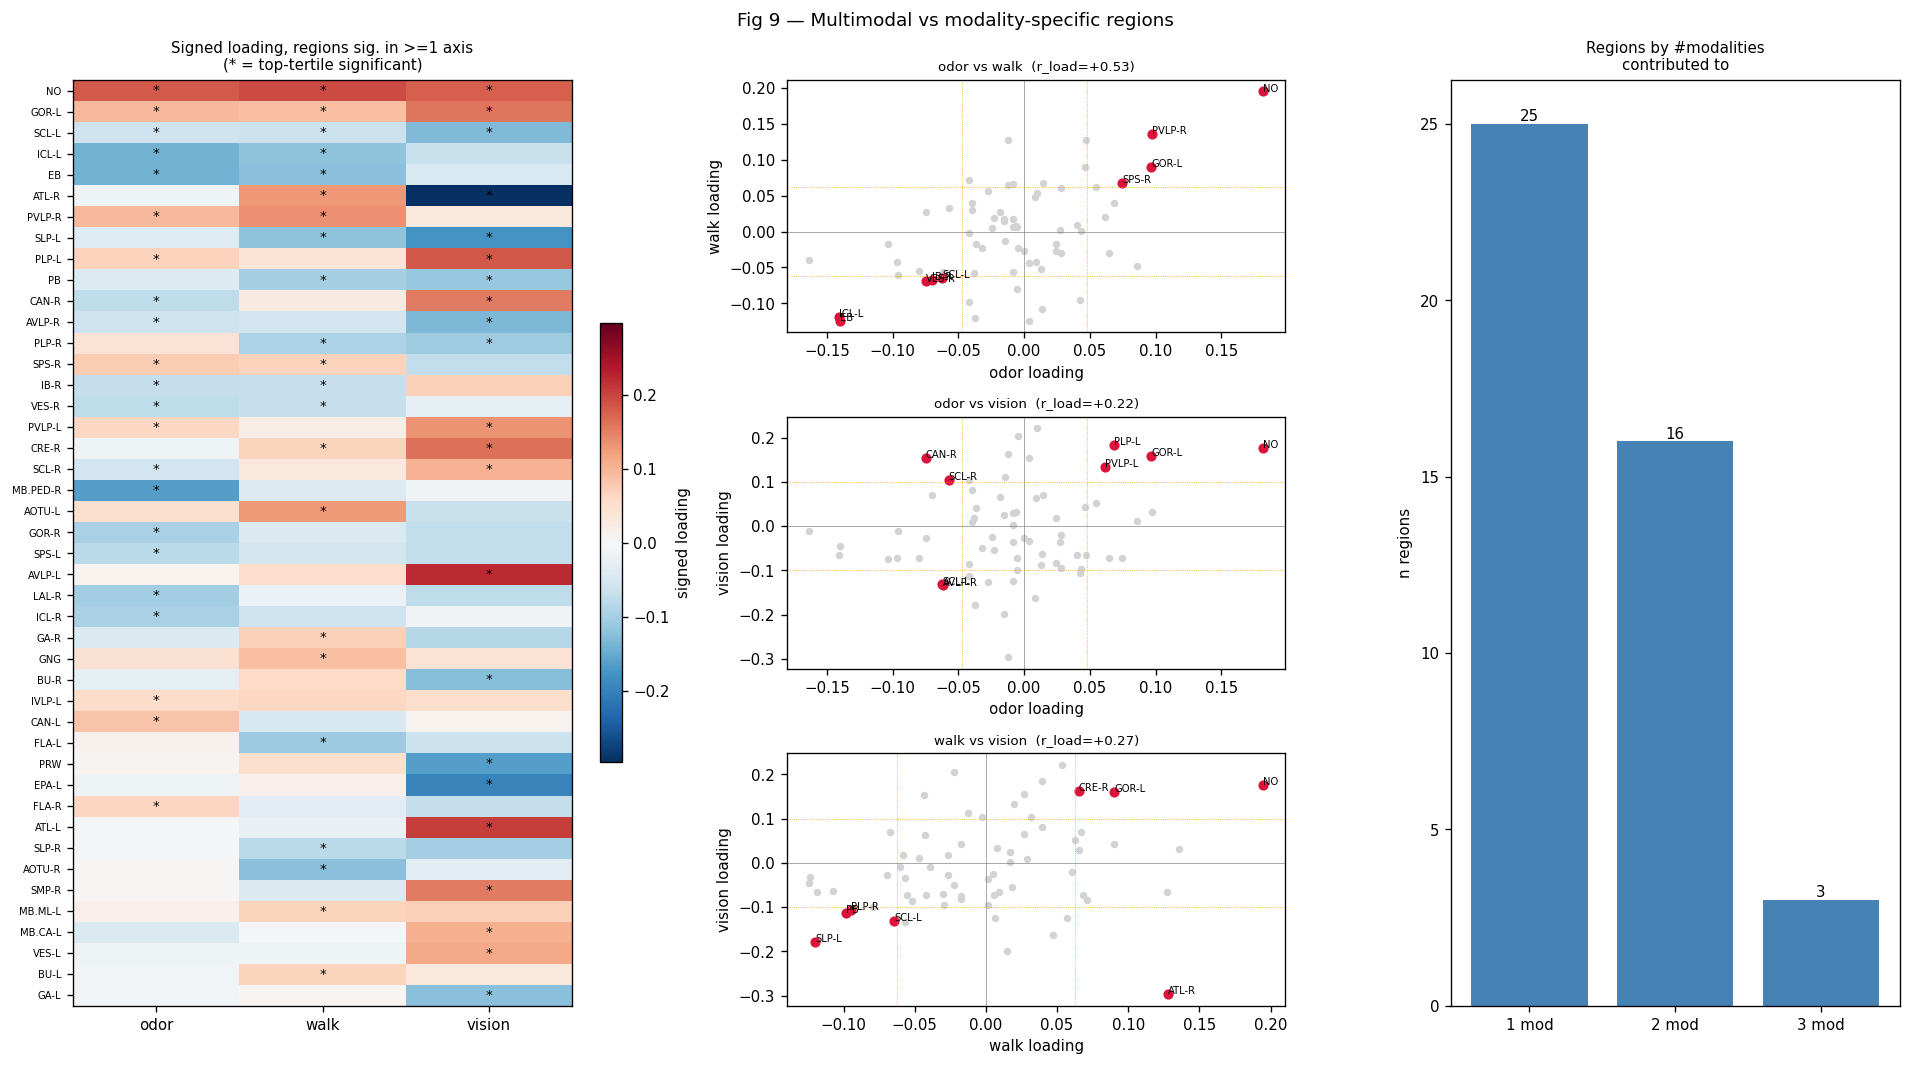

In [29]:
import itertools
mods = list(MODALITIES)
absL = {m: np.abs(loading[m]) for m in mods}
thr  = {m: np.nanpercentile(absL[m], 66.7) for m in mods}    # top-tertile significance
sig  = {m: (absL[m] >= thr[m]) for m in mods}                # NaN -> False
count = np.nansum([sig[m].astype(float) for m in mods], 0)   # 0..3 contributions per region

# --- axis (non-)orthogonality caveat ---
print('Decoder-axis cosine (factor space) | region-loading correlation:')
for a, b in itertools.combinations(mods, 2):
    pa = ~(np.isnan(loading[a]) | np.isnan(loading[b]))
    r = np.corrcoef(loading[a][pa], loading[b][pa])[0, 1]
    print(f'  {a}-{b}: cos={w_mod[a] @ w_mod[b]:+.2f}  r_load={r:+.2f}')

def names(mask): return [REGION_NAMES[i] for i in np.where(mask)[0]]
tri = sig['odor'] & sig['walk'] & sig['vision']
print(f'\nTrimodal (all 3 axes): {names(tri)}')
for a, b in itertools.combinations(mods, 2):
    print(f'  {a}&{b}: {names(sig[a] & sig[b])}')

# --- Figure: significance heatmap (regions sig. in >=1 axis) + pairwise scatters + count bar ---
sigreg = np.where(count >= 1)[0]
order = sorted(sigreg, key=lambda i: (count[i],
              np.nansum([absL[m][i] / thr[m] for m in mods])), reverse=True)
Lsig = np.stack([loading[m][order] for m in mods], 1)        # (n_sig, 3) signed

fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(3, 3, width_ratios=[1.1, 1, 0.9])
axh = fig.add_subplot(gs[:, 0])
vmax = np.nanmax(np.abs(Lsig)); cmap = plt.get_cmap('RdBu_r').copy(); cmap.set_bad('lightgrey')
im = axh.imshow(np.ma.masked_invalid(Lsig), aspect='auto', cmap=cmap, vmin=-vmax, vmax=vmax)
axh.set_xticks(range(3)); axh.set_xticklabels(mods)
axh.set_yticks(range(len(order))); axh.set_yticklabels([REGION_NAMES[i] for i in order], fontsize=6)
for r, i in enumerate(order):
    for c, m in enumerate(mods):
        if sig[m][i]:
            axh.text(c, r, '*', ha='center', va='center', fontsize=8)
axh.set_title('Signed loading, regions sig. in >=1 axis\n(* = top-tertile significant)', fontsize=9)
fig.colorbar(im, ax=axh, fraction=0.04, label='signed loading')

for k, (a, b) in enumerate(itertools.combinations(mods, 2)):
    ax = fig.add_subplot(gs[k, 1])
    ax.axhline(0, color='grey', lw=0.4); ax.axvline(0, color='grey', lw=0.4)
    for s in (1, -1):
        ax.axvline(s * thr[a], color='orange', lw=0.5, ls=':')
        ax.axhline(s * thr[b], color='orange', lw=0.5, ls=':')
    pa = ~(np.isnan(loading[a]) | np.isnan(loading[b]))
    ax.scatter(loading[a][pa], loading[b][pa], s=12, c='lightgrey')
    both = sig[a] & sig[b]
    ax.scatter(loading[a][both], loading[b][both], s=26, c='crimson')
    for i in np.where(both)[0]:
        ax.annotate(REGION_NAMES[i], (loading[a][i], loading[b][i]), fontsize=6)
    ax.set_xlabel(f'{a} loading'); ax.set_ylabel(f'{b} loading')
    ax.set_title(f'{a} vs {b}  (r_load={np.corrcoef(loading[a][pa], loading[b][pa])[0,1]:+.2f})',
                 fontsize=8)

axc = fig.add_subplot(gs[:, 2])
cats, ncat = np.unique(count[count >= 1].astype(int), return_counts=True)
axc.bar([f'{c} mod' for c in cats], ncat, color='steelblue')
axc.set_ylabel('n regions'); axc.set_title('Regions by #modalities\ncontributed to', fontsize=9)
for x, (c, n) in enumerate(zip(cats, ncat)):
    axc.text(x, n, str(n), ha='center', va='bottom', fontsize=9)
fig.suptitle('Fig 9 — Multimodal vs modality-specific regions', fontsize=11)
plt.tight_layout(); plt.show()

## Fig 10 — How reliable is the region encoding per fly?

Fig 8/9 average `W_f @ w_mod` over the 5 flies. Here we keep the per-fly values to judge reliability:

- **strip plots** of each fly's loading for the top regions (red ◆ = across-fly mean);
- each region's label shows **sign-consistency** (fraction of flies agreeing with the mean sign) and
  **#flies present** — a region present in only 1-2 flies (e.g. `MED-L`) is *not* reliably estimated
  and should be discounted even if its mean loading is large;
- **axis reproducibility** (panel titles): cosine between each fly's *own* logistic axis (fit on its
  own 16 trials) and the pooled axis. ~0.4 means the shared axis is a population-average direction,
  not tightly reproduced per fly — a direct consequence of only 16 trials/fly.

Trustworthy encodings = present in all flies with high sign-consistency (e.g. `AOTU-R`→vision,
`CRE-R`→vision); low-consistency or few-fly regions are provisional.

> Optic-lobe artifact regions (`ARTIFACT_REGIONS`, set by `ARTIFACT_BASES`) are **excluded** from the rankings/hubs below and shown grey in the heatmaps.

Per-fly decoder-axis cosine vs pooled axis (axis reproducibility):
  odor  : +0.39 +/- 0.18  per-fly [0.57, 0.43, 0.03, 0.49, 0.43]
  walk  : +0.53 +/- 0.13  per-fly [0.73, 0.56, 0.49, 0.34, 0.56]
  vision: +0.37 +/- 0.19  per-fly [0.37, 0.47, 0.04, 0.37, 0.6]


/tmp/ipykernel_1804241/1704382015.py:32: RuntimeWarning: Mean of empty slice
  P = perfly[m]; mean = np.nanmean(P, 0); sc = sign_consistency(P)
/tmp/ipykernel_1804241/1704382015.py:26: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(P, 0)
/tmp/ipykernel_1804241/1704382015.py:32: RuntimeWarning: Mean of empty slice
  P = perfly[m]; mean = np.nanmean(P, 0); sc = sign_consistency(P)
/tmp/ipykernel_1804241/1704382015.py:26: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(P, 0)
/tmp/ipykernel_1804241/1704382015.py:32: RuntimeWarning: Mean of empty slice
  P = perfly[m]; mean = np.nanmean(P, 0); sc = sign_consistency(P)
/tmp/ipykernel_1804241/1704382015.py:26: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(P, 0)


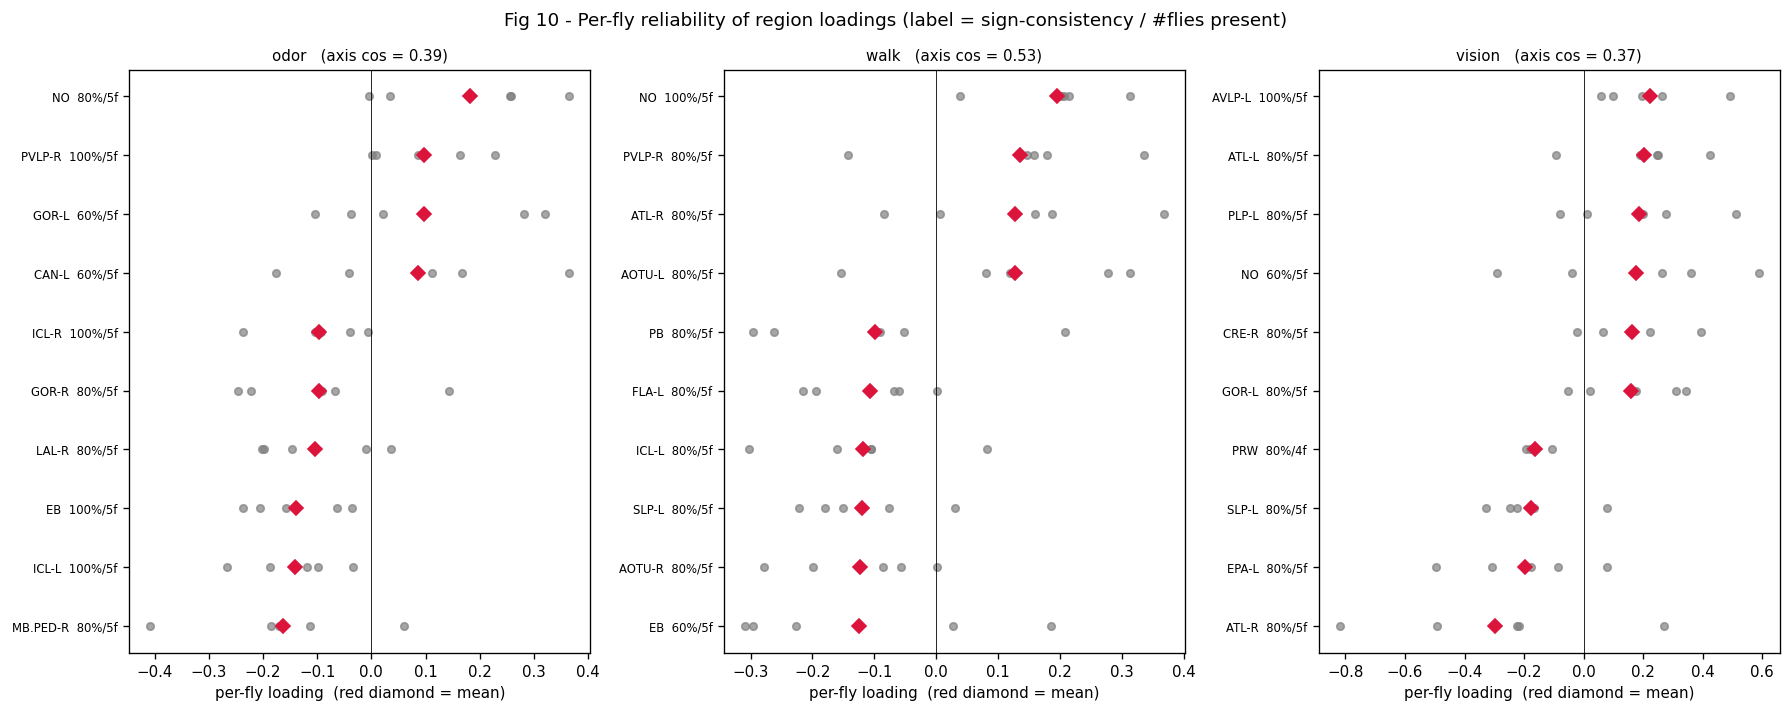

In [30]:
# per-fly loadings (shared axis W_f @ w_mod), lifted to canonical frame -> (n_flies, 75)
perfly = {m: np.stack([to_canon(readout_W[s] @ w_mod[m], s) for s in fly_stems], 0)
          for m in mods}
for _m in perfly:                # exclude flagged optic-lobe artifact regions
    perfly[_m][:, ARTIFACT_MASK] = np.nan
n_present = {m: np.sum(~np.isnan(perfly[m]), 0) for m in mods}

# per-fly decoder axes (fit on each fly alone) vs the pooled axis -> reproducibility of the axis
axis_cos = {}
for m in mods:
    cs = []
    for s in fly_stems:
        ys = targets[s][m].reshape(-1)
        if len(np.unique(ys)) < 2:
            continue
        wf = LogisticRegression(class_weight='balanced', max_iter=1000).fit(
            fly_data[s]['factors'].reshape(-1, n_fac), ys).coef_.reshape(-1)
        cs.append(float((wf / (np.linalg.norm(wf) + 1e-12)) @ w_mod[m]))
    axis_cos[m] = cs
print('Per-fly decoder-axis cosine vs pooled axis (axis reproducibility):')
for m in mods:
    print(f'  {m:6s}: {np.mean(axis_cos[m]):+.2f} +/- {np.std(axis_cos[m]):.2f}  '
          f'per-fly {[round(c, 2) for c in axis_cos[m]]}')

def sign_consistency(P):
    mean = np.nanmean(P, 0)
    return np.array([np.nanmean(np.sign(P[:, i]) == np.sign(mean[i]))
                     if np.sum(~np.isnan(P[:, i])) else np.nan for i in range(N_REGIONS)])

fig, axes = plt.subplots(1, len(mods), figsize=(5 * len(mods), 6))
for ax, m in zip(axes, mods):
    P = perfly[m]; mean = np.nanmean(P, 0); sc = sign_consistency(P)
    elig = np.where(n_present[m] >= 3)[0]                      # need >=3 flies to be shown
    top = elig[np.argsort(np.abs(mean[elig]))[::-1][:10]]
    top = top[np.argsort(mean[top])]                          # sort for display
    for r, i in enumerate(top):
        vals = P[:, i][~np.isnan(P[:, i])]
        ax.scatter(vals, [r] * len(vals), s=20, color='grey', alpha=0.7, zorder=2)
        ax.plot([mean[i]], [r], 'D', color='crimson', ms=6, zorder=3)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([f'{REGION_NAMES[i]}  {sc[i]:.0%}/{n_present[m][i]}f' for i in top],
                       fontsize=7)
    ax.set_xlabel('per-fly loading  (red diamond = mean)')
    ax.set_title(f'{m}   (axis cos = {np.mean(axis_cos[m]):.2f})', fontsize=9)
fig.suptitle('Fig 10 - Per-fly reliability of region loadings '
             '(label = sign-consistency / #flies present)', fontsize=11)
plt.tight_layout(); plt.show()

## Notes and caveats

- **Rotation ambiguity**: factor indices have no canonical meaning — LFADS finds a
  rotation-free subspace. Individual factor numbers change across runs.
  For stable interpretability, rotate factors to stimulus directions (e.g., PCA of
  condition-mean factors) before reading off per-factor region loadings.

- **PCR initialization**: readout weights start as `pinv(W_readin)` (see
  `how_multisession_lfads.md`). Training refines from there. If training converged
  quickly, readout ≈ pinv(readin) and both reflect the PCR alignment, not purely
  neural structure.

- **16 trials per fly**: with limited data, variational inference may be poorly
  constrained. Treat loadings as indicative rather than quantitatively precise.

- **Factors → condition directions**: for the cleanest region-level story, project
  factors onto stimulus PCs (e.g., odour axis, walking axis) first, then ask which
  regions load onto those named axes.